# Calibration and validation of the image segmentation method

Each portion of the calibration and validation requires tuning of some sort.
1. Preprocessing: histogram clipping parameter, especially.
2. Binarization: Window size, choice of $k$, cluster selection method.
3. Morphological cleanup
4. Dist-Morph-Split algorithm
5. Merging floes
6. Filtering final results

## Binarization
The $k$-means segmentation method works well for identifying bright regions. I use different settings for the bright ice detection for the cloudy and clear-sky regions of the image. The calibration here is simple: I took the average band 7 and band 2 brightness from the manually validated floe shapes, categorized by IFT cloud cover.


TBD:
* Demonstration figure showing the preprocessing steps, with image details. Big Q: Does the perona-malik method actually help? It's rather slow to compute.
* Panels to clarify the dist-morph-split algorithm results, writing to describe the optimization.
* Panels to clarify the floe merging results. Can we include a distance(feature) transform to assist in the merges? What prevents a small round floe from overrulling a large floe?
* Figure to show the floe-wise distributions used for the final filtering approach. (Should it be before or after the merge?)



What can the classification maps tell us about the k-means segmentation? And can it work better than using the "bright ice fraction"? Because ice and clouds look similar in the k-means result, we can have cases where the clouds are contained within the same k-means cluster which contains the sea ice floes. In the previous version of the IFT, we use a the metric of finding the highest fraction of pixels which are higher than the histogram peak for bands 1 or 2. This is a reasonable approach which works decently well for our analyses.

In order to get to a result with the segmentation analyses we need to have a reasonable metric of success. The target is to get as many of the true floe shapes -- really the floe boundaries -- as possible. The image contains a lot of usable information, which we need to link together. The classification results give us a pretty good idea of what the material in the image is. K-means gives pretty good pictures of the image type, but the choice of k matters, and isn't always right -- is there a clue in the image to say whether we should use one number or other? 

From the validation dataset we have a ton of examples of images where we don't actually want to run the segmentation. We can set thresholds for the number of detected ice pixels to run the algorithm. Or we could follow what was done in the earlier version of the algorithm with the statistics of the cloud-covered but floe-containing images. So really there is a need for a filtering step to decide whether to analyze the tile. 

We can focus first on clear sky cases where there may or may not be ice floes present.



In [1]:
using Pkg
Pkg.activate("../scripts/calval")
# Pkg.update(; name="IceFloeTracker", rev="main")
using IceFloeTracker
using Images
using Random
using DataFrames
using StatsBase
using CairoMakie

include("../scripts/dev/segmentation.jl")

  Activating project at `~/Documents/research/manuscripts/calval_tgrs/scripts/calval`


colorize_classification (generic function with 1 method)

In [2]:
dataset = Watkins2026Dataset(;
    url="https://github.com/danielmwatkins/ice-floe-validation-dataset/",
    ref="v0.2",
    cache_dir="/tmp/Watkins2026",
    metadata_path="data/validation_dataset/validation_dataset.csv",
)
# Add a column to indicate whether water samples have been generated yet
nothing

In [3]:
import IceFloeTracker.FSPipeline: clean_binary_floes, dist_morph_split
kmeans_params = (
    k=4,
    maxiter=50,
    random_seed=45,
    cluster_selection_algorithm=IceDetectionBrightnessPeaksMODIS721(;
        band_7_max=0.16,
        possible_ice_threshold=0.6,
        join_method="union",
        minimum_prominence=0.01,
    ),
)
adaptive_params = (window_size=400, percentage=0)
cleanup_binary_params = (
    erosion_strel=strel_box((3, 3)), init_max_fill=100, conditional_max_fill=500
)
floe_splitting_params = (max_hole_fill=2000, max_distance=5, max_expand=3)
floe_filtering_params = (
    min_floe_size=100,
    max_floe_size=90_000,
    boundary_radius=15,
    min_circularity=0.3,
    min_solidity=0.7,
    min_reflectance=0.4,
    min_contrast=0.01,
    min_probability=0.5,
)
floe_merging_params = (
    distance_threshold_pixels=10, area_error_threshold=0.25, min_floe_size=100
)

cloud_mask_function = Watkins2026CloudMask(
    band_7_threshold=0.16,
    band_2_threshold=0.34,
    opening_strel=strel_disk(3),
    dilation_strel=strel_disk(2)
)

ice_mask_function = IceDetectionBrightnessMidpoint(; minimum_reflectance=0.45)

function keep_labels!(img_indexmap, labels_list)    
    indices = component_indices(img_indexmap)
    labels = filter(r -> r > 0, unique(img_indexmap))
    for L in labels
        if L ∉ labels_list
            img_indexmap[indices[L]] .= 0
        end
    end
end


function Segment(preproc_gray, fc_masked, ice_mask, land_mask, coastal_buffer, cloud_mask)
    water_mask = land_mask .|| .!(ice_mask .|| cloud_mask)
    adaptive_result = apply_landmask(
        binarize(preproc_gray, AdaptiveThreshold(; adaptive_params...)) .> 0,
        water_mask .|| land_mask
    )
    kmeans_result = kmeans_binarization(
        preproc_gray, fc_masked; kmeans_params...
    ) # question of whether preproc gray should have the water mask applied or not
    clean_and_split(r) = dist_morph_split(
            clean_binary_floes(
                r, ice_mask, cloud_mask; cleanup_binary_params...
            );
        floe_splitting_params...,
    )
    labeled_images = clean_and_split.([kmeans_result, adaptive_result])
    filtered_floes = filter_floes.(labeled_images, [coastal_buffer], [cloud_mask], [fc_masked]; floe_filtering_params...)
    keep_labels!.(labeled_images, filtered_floes .|> r -> r.label)   
    final_floes = merge_floes(filtered_floes..., labeled_images...)
    return label_components(final_floes)
end

Segment (generic function with 1 method)

## Sample selection
Stratify sample on the presence of sea ice floes, then randomly divide into testing and training groups. For each case, randomly select either Aqua or Terra.

In [4]:
#### Run this to re-draw the sample ####
redraw_sample = false
if redraw_sample
    # Generate stratified train/test samples
    min_floe_size = 64
    fraction = 2/3
    seed = 20
    rng = Random.default_rng(seed)
    df = dataset.info
    max_floe_sizes = Int64.(coalesce.(df[!, :maximum_floe_size], 0));
    df[:, :ice_floes] = max_floe_sizes .> min_floe_size
    
    gdf = groupby(df[df.satellite .== "aqua",:], :ice_floes)
    train_data = []
    test_data = []
    for group in gdf
        n = round(Int64, fraction * nrow(group))
        idx_all = 1:nrow(group)
        train_idx = StatsBase.sample(rng, idx_all, n; replace=false, ordered=true)
        test_idx = [x for x ∈ idx_all if x ∉ train_idx]
        push!(train_data, group[train_idx, :])
        push!(test_data, group[test_idx, :])    
    end
    train_df = reduce(vcat, train_data)
    test_df = reduce(vcat, test_data);
    df[:, :train] = [x ∈ train_df.case_number for x in df.case_number]
    satellite = StatsBase.sample(["aqua", "terra"], maximum(df.case_number); replace=true)
    training = [x ∈ train_df.case_number for x in df.case_number]
    
    # Now add a Boolean column to the dataset object, so we can filter on it.
    dataset.info[:, :training_sample] .= [
        (s == satellite[cn]) && training[cn] for (cn, s) in zip(dataset.info.case_number, dataset.info.satellite)
            ];
    dataset.info[:, :testing_sample] .= [
        (s == satellite[cn]) && !training[cn] for (cn, s) in zip(dataset.info.case_number, dataset.info.satellite)
            ];
    # Now: get the training and testing data, single image per case.
    train_cases = filter(c -> c.training_sample, dataset) 
    test_cases = filter(c -> c.testing_sample, dataset);
    
    save("../data/segmentation_train_test_split.csv", dataset.info)
end

## Load previously saved sample

In [5]:
#### Run this to use the previously defined test/train split ####
prior_data = DataFrame(load("../data/train_test_split.csv"))
dataset.info[:, :training_sample] = parse.(Bool, prior_data[:, :training_sample])
dataset.info[:, :testing_sample] = parse.(Bool, prior_data[:, :testing_sample])
train_cases = filter(c -> c.training_sample, dataset) 
test_cases = filter(c -> c.testing_sample, dataset);

train_cases.info[:, :lookup_index] = 1:nrow(train_cases.info)
test_cases.info[:, :lookup_index] = 1:nrow(test_cases.info);

### Step two: Setup images
Load tc and fc images, apply masks to TC and FC images, and get the cloud and prelim ice masks

In [6]:
case = train_cases
classifier = Classify()
@time begin
    tc_imgs = modis_truecolor.(case)
    fc_imgs = modis_falsecolor.(case)
    land_masks = modis_landmask.(case) .|> r -> r .> 0
    coastal_buffers = create_coastal_buffer_mask.(land_masks, [strel_disk(25)])
    classified_imgs = classifier.(fc_imgs, land_masks)
    # reference images
    binary_floes = validated_binary_floes.(case)
    fill_missing!(binary_floes)
    manual_labeled = label_components.(binary_floes);
    manual_landfast = validated_binary_landfast.(case)
end
nothing

 23.350975 seconds (47.93 M allocations: 4.688 GiB, 8.66% gc time, 34.45% compilation time: 4% of which was recompilation)


In [7]:
fill_missing!(manual_landfast)

In [8]:
# Data table: Fraction of ocean pixels in each category.
get_fraction(r, key) = round(sum(r .== classifier.key[key]) ./ sum(r .!= classifier.key["land"]), digits=2)
ice_fractions = get_fraction.(classified_imgs, "ice")
cloud_fractions = get_fraction.(classified_imgs, "cloud")
water_fractions = get_fraction.(classified_imgs, "water")
train_cases.info[:, "ift_ice_fraction"] .= ice_fractions
train_cases.info[:, "ift_cloud_fraction"] .= cloud_fractions
train_cases.info[:, "ift_water_fraction"] .= water_fractions;

# Selecting cases for training
1. We use all the detected floes in selecting true and false positives, fitting the logistic regression function, and setting the parameters
2. We use the cases with good floe visibility to set up the merging method

## Parameters for image binarization

The $k$-means method uses a separate "bright floes" criterion for cloud-covered and clear-sky cases. We use the distribution of floe-average brightness in the manually labeled dataset to determine the max band 7 and min band 1/2 values for this step.

In [9]:
# TODO: Loop through training cases with floe data, get segment data
sea_ice_floe_cases = subset(coalesce.(train_cases.info, 0), :maximum_floe_size => r -> r .> 64);
masks = Dict(idx => Dict(
        k => classified_imgs[idx] .== classifier.key[k] for k in keys(classifier.key)
        ) for idx in 1:length(classified_imgs)
    )

df_list = []
for df_row in eachrow(sea_ice_floe_cases)
    idx = df_row.lookup_index
    df_case = extended_regionprops(
        manual_labeled[idx],
        fc_imgs[idx],
        masks[idx]
        )
    df_case[:, :case_number] .= df_row.case_number
    df_case[:, :lookup_index] .= idx
    push!(df_list, df_case)
end

df_all = vcat(df_list..., cols=:union)

nothing

In [ ]:
names(df_all)

## Visualize the joint distribution of floe-mean reflectance

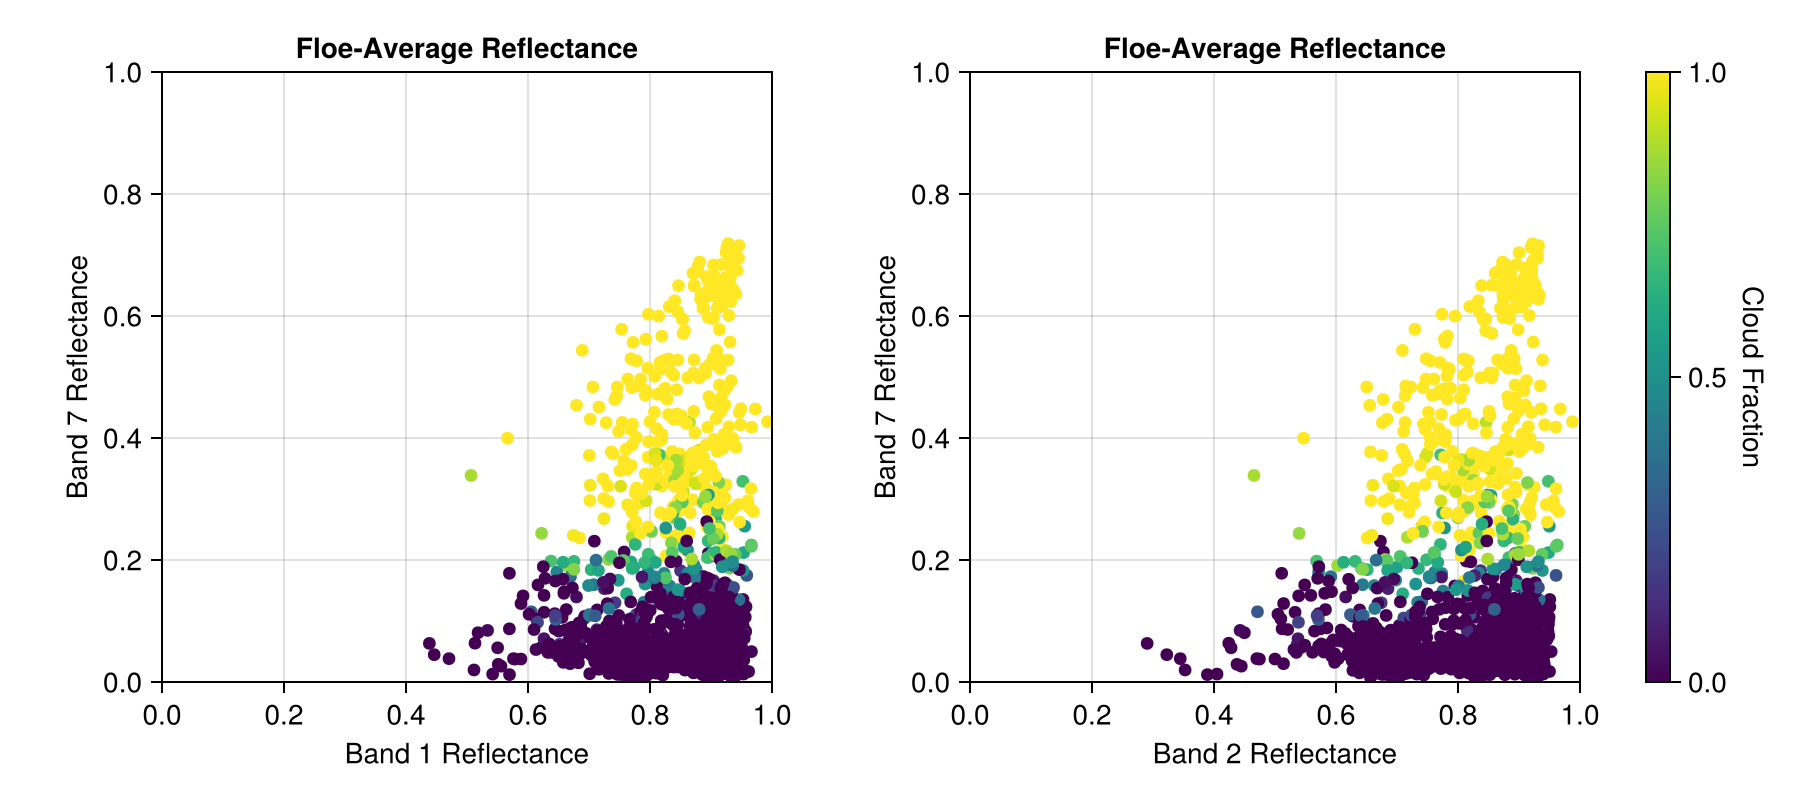

In [10]:
f = CairoMakie.Figure(size=(900, 400))
ax1 = CairoMakie.Axis(f[1, 1], title="Floe-Average Reflectance",
    ylabel="Band 7 Reflectance", xlabel="Band 1 Reflectance", aspect=1,
    yticks=0:0.2:1, xticks=0:0.2:1, limits=(0, 1, 0, 1))
a = scatter!(ax1, df_all[:, :b1_reflectance_mean], df_all[:, :b7_reflectance_mean], color=df_all[:, :cloud_fraction], colormap=:viridis)
ax2 = CairoMakie.Axis(f[1, 2], title="Floe-Average Reflectance",
    ylabel="Band 7 Reflectance", xlabel="Band 2 Reflectance", aspect=1,
    yticks=0:0.2:1, xticks=0:0.2:1, limits=(0, 1, 0, 1))
a = scatter!(ax2, df_all[:, :b2_reflectance_mean], df_all[:, :b7_reflectance_mean], color=df_all[:, :cloud_fraction], colormap=:viridis)
Colorbar(f[1, 3], a; label="Cloud Fraction", labelrotation=-pi/2)

f

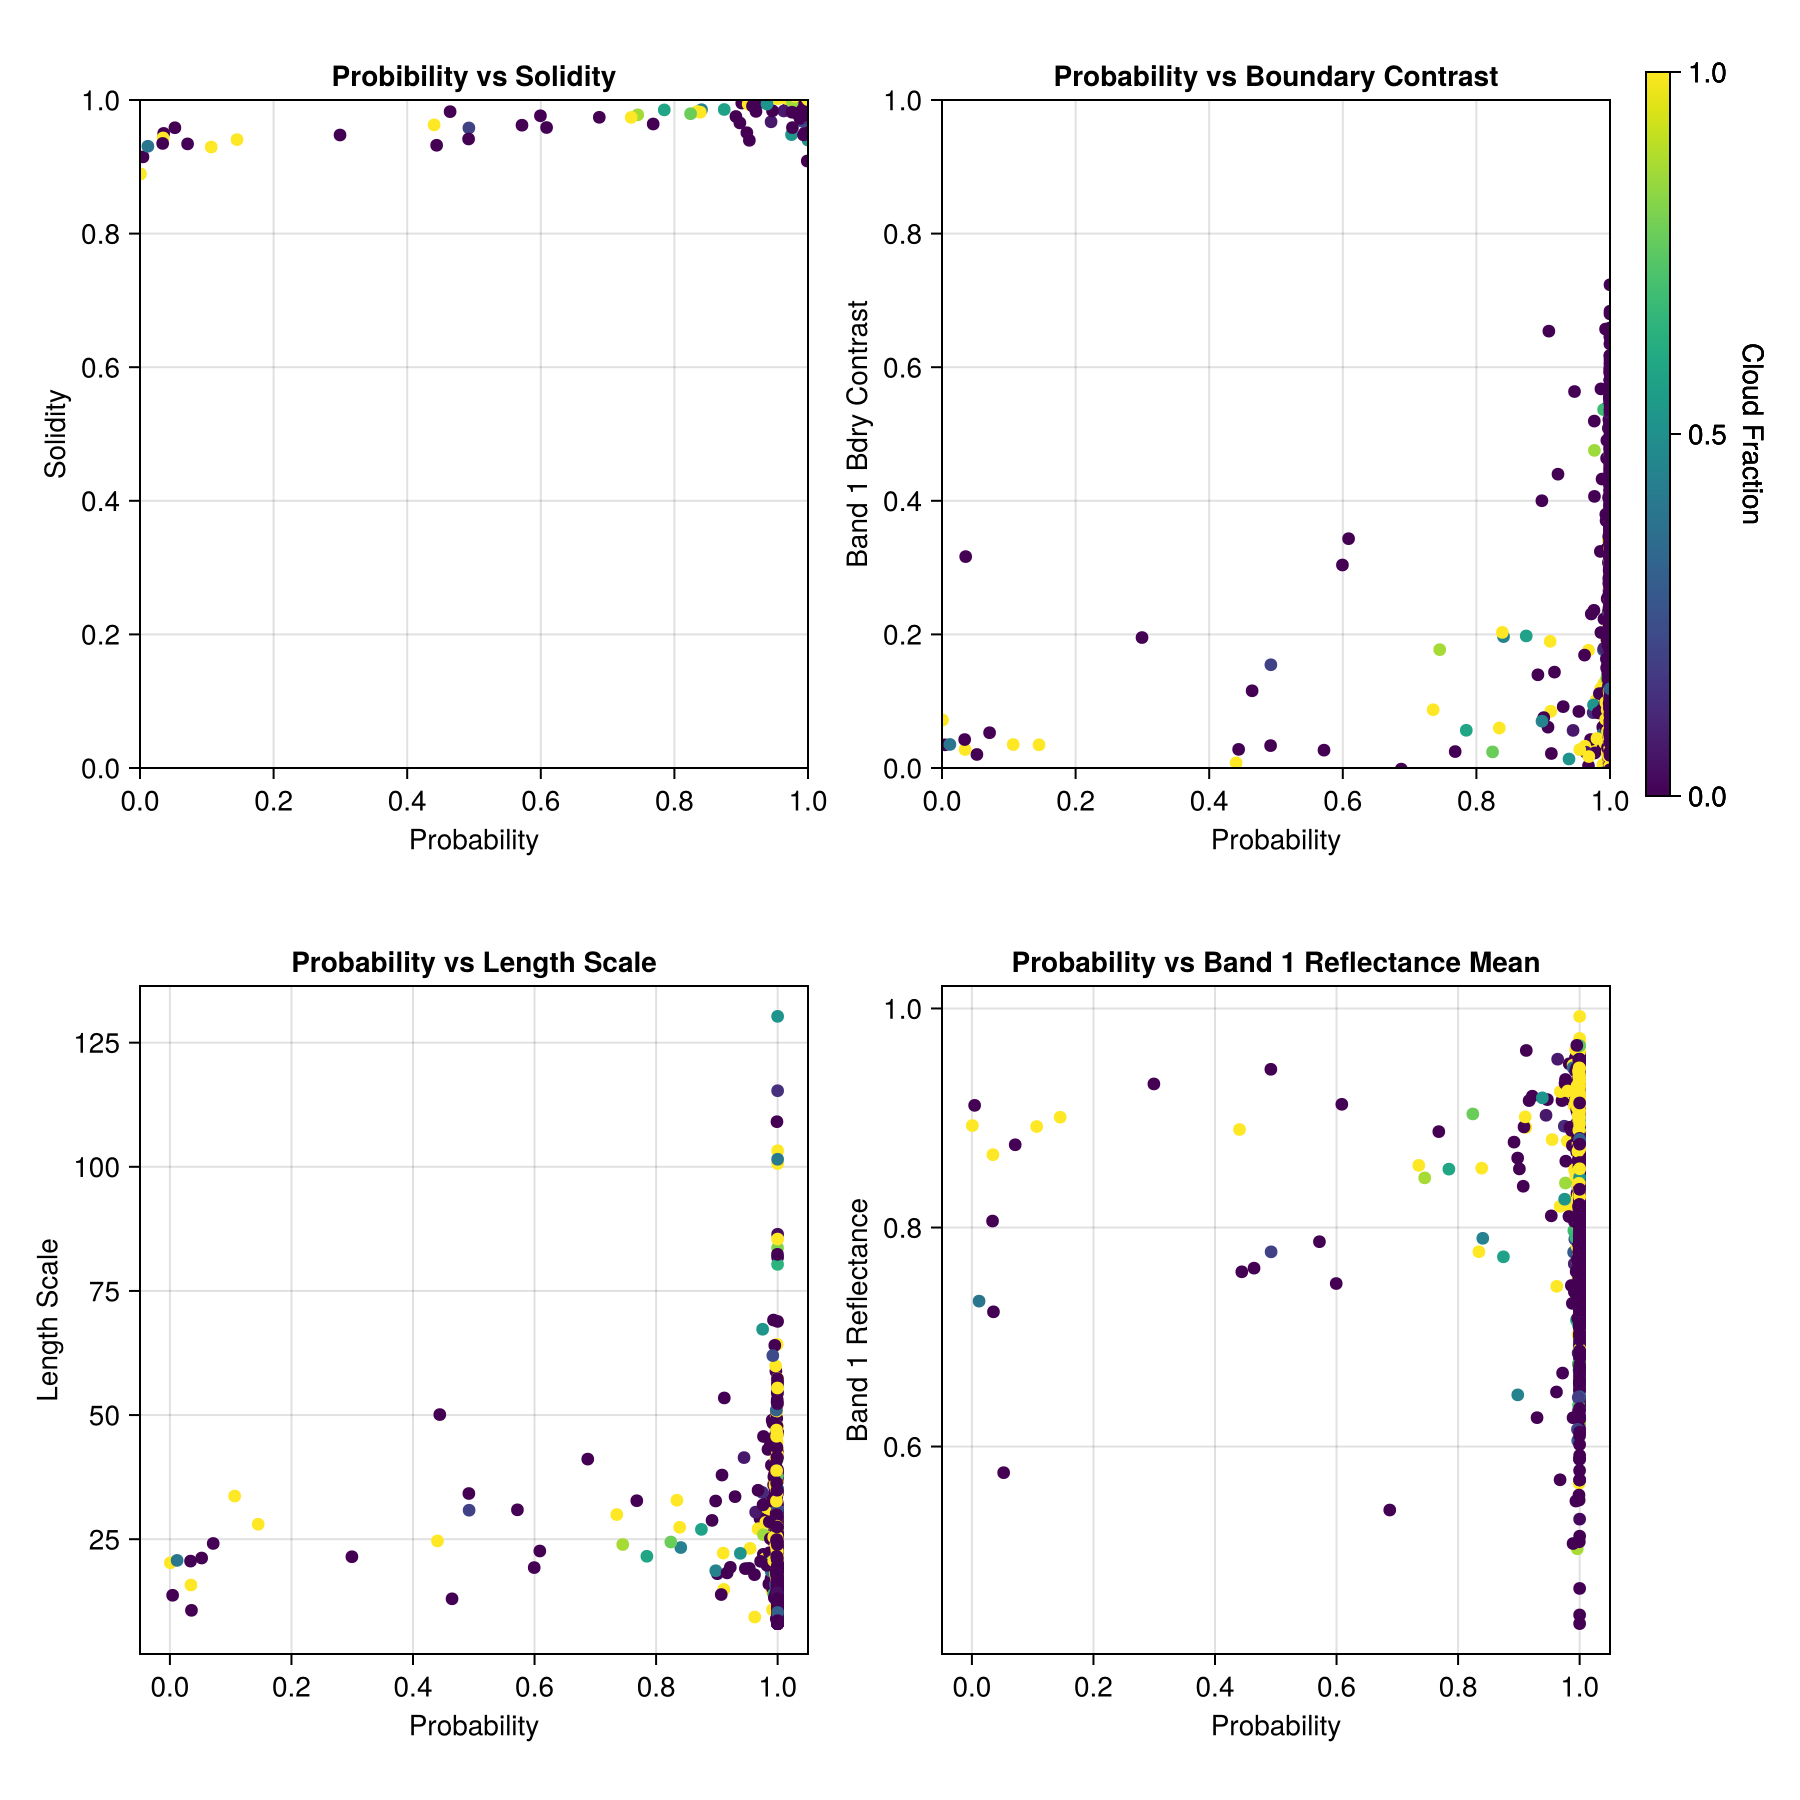

In [11]:
f = CairoMakie.Figure(size=(900, 900))
ax1 = CairoMakie.Axis(f[1, 1], title="Probibility vs Solidity",
    ylabel="Solidity", xlabel="Probability", aspect=1,
    yticks=0:0.2:1, xticks=0:0.2:1, limits=(0, 1, 0, 1))
a = scatter!(ax1, df_all[:, :probability], df_all[:, :solidity], color=df_all[:, :cloud_fraction], colormap=:viridis)
ax2 = CairoMakie.Axis(f[1, 2], title="Probability vs Boundary Contrast",
    ylabel="Band 1 Bdry Contrast", xlabel="Probability", aspect=1,
    yticks=0:0.2:1, xticks=0:0.2:1, limits=(0, 1, 0, 1))
a = scatter!(ax2, df_all[:, :probability], df_all[:, :b1_bdry_contrast], color=df_all[:, :cloud_fraction], colormap=:viridis)
Colorbar(f[1, 3], a; label="Cloud Fraction", labelrotation=-pi/2)

ax3 = CairoMakie.Axis(f[2, 1], title="Probability vs Length Scale",
    ylabel="Length Scale", xlabel="Probability", aspect=1,
     xticks=0:0.2:1) #, limits=(0, 1, 0, 1))
a = scatter!(ax3, df_all[:, :probability], df_all[:, :area].^0.5, color=df_all[:, :cloud_fraction], colormap=:viridis)
Colorbar(f[1, 3], a; label="Cloud Fraction", labelrotation=-pi/2)


ax4 = CairoMakie.Axis(f[2, 2], title="Probability vs Band 1 Reflectance Mean",
    ylabel="Band 1 Reflectance", xlabel="Probability", aspect=1,
     xticks=0:0.2:1) #, limits=(0, 1, 0, 1))
a = scatter!(ax4, df_all[:, :probability], df_all[:, :b1_reflectance_mean], color=df_all[:, :cloud_fraction], colormap=:viridis)
Colorbar(f[1, 3], a; label="Cloud Fraction", labelrotation=-pi/2)


f

In [12]:
mean(df_all.probability .> 0.5), sum(df_all.probability .< 0.5)

(0.9900990099009901, 16)

In [13]:
df_all[df_all.probability .> 0.5, [:case_number, :lookup_index, :b1_reflectance_mean, :area, :cloud_fraction]]

Row,case_number,lookup_index,b1_reflectance_mean,area,cloud_fraction
,Int64,Int64,Float64,Int64,Float64
1,1,1,0.753542,581,1.0
2,1,1,0.814289,4127,1.0
3,1,1,0.691683,733,0.155525
4,1,1,0.686518,129,0.0
5,1,1,0.566389,191,1.0
6,1,1,0.67948,86,1.0
7,1,1,0.79687,327,0.458716
8,1,1,0.506636,354,0.872881
9,1,1,0.518137,88,0.0


In [14]:
println("Clear sky, Band 7 maximum: ", round(percentile(df_all[df_all.cloud_fraction .< 0.2, :b7_reflectance_mean], 99), digits=2))
println("Clear sky, Band 2 minimum: ", round(percentile(df_all[df_all.cloud_fraction .< 0.2, :b2_reflectance_mean], 1), digits=2))
println("Clear sky, Band 1 minimum: ", round(percentile(df_all[df_all.cloud_fraction .< 0.2, :b1_reflectance_mean], 1), digits=2))
println("Cloudy, Band 7 maximum: ", round(percentile(df_all[df_all.cloud_fraction .> 0.2, :b7_reflectance_mean], 99), digits=2))
println("Cloudy, Band 2 minimum: ", round(percentile(df_all[df_all.cloud_fraction .> 0.2, :b2_reflectance_mean], 1), digits=2))
println("Cloudy, Band 1 minimum: ", round(percentile(df_all[df_all.cloud_fraction .> 0.2, :b1_reflectance_mean], 1), digits=2))

Clear sky, Band 7 maximum: 0.18
Clear sky, Band 2 minimum: 0.46
Clear sky, Band 1 minimum: 0.57
Cloudy, Band 7 maximum: 0.7
Cloudy, Band 2 minimum: 0.56
Cloudy, Band 1 minimum: 0.63


## Sensitivity test: k-means binarization
At this stage we expect high recall, and will aim to improve the precision as we refine the floe shapes. 

In [16]:
key = Classify().key

function _kmeans_binarization(preproc_gray, falsecolor_image, classified_image;
    cloudy_params=(k=3, b7=0.7, b2=0.56),
    clearsky_params=(k=4, b7=0.15, b2=0.46)
    )
    masks = Dict(k => classified_image .== key[k] 
                    for k in keys(key)
    )
    fc_masked = apply_landmask(falsecolor_image, masks["land"])
    
    # This can be a method or an input function
    cloudy_ice_detector = IceDetectionBrightnessPeaksMODIS721(
        band_7_max=cloudy_params.b7,
        possible_ice_threshold=cloudy_params.b2,
        nbins=128, minimum_prominence=0.03)
    clear_sky_ice_detector = IceDetectionBrightnessPeaksMODIS721(
        band_7_max=clearsky_params.b7,
        possible_ice_threshold=clearsky_params.b2,
        nbins=128, minimum_prominence=0.01);

    cloudy_kmeans = kmeans_binarization(preproc_gray, fc_masked;
        k=cloudy_params.k, cluster_selection_algorithm=cloudy_ice_detector
    ) .> 0
    clear_kmeans = kmeans_binarization(preproc_gray, fc_masked;
        k=clearsky_params.k, cluster_selection_algorithm=clear_sky_ice_detector
    ) .> 0
    
    clear_kmeans[masks["cloud"]] .= cloudy_kmeans[masks["cloud"]]

    return clear_kmeans
end
# No tiles at this stage, we can check that performance later
preproc_gray = Preprocess().(tc_imgs, land_masks)
binarized_imgs = _kmeans_binarization.(preproc_gray, fc_imgs, classified_imgs);

In [ ]:
mosaicview([Gray.(binarized_imgs[idx]) for idx in 1:2:20]..., nrow=2)

# Illustrating basic scores

In [ ]:
# scores 
idx = 15
ice_labels = (manual_landfast[idx] .+ binary_floes[idx]) .> 0
true_pos = binarized_imgs[idx] .&& ice_labels
false_pos = binarized_imgs[idx] .&& .!ice_labels
true_neg = .!binarized_imgs[idx] .&& .!ice_labels .&& .!land_masks[idx]
false_neg = .!binarized_imgs[idx] .&& ice_labels
println("Left to right: True positive, false positive, true negative, false negative")
mosaicview(Gray.(true_pos), Gray.(false_pos), Gray.(true_neg), Gray.(false_neg), nrow=1)

In [ ]:
results_init = DataFrame(
    true_pos=Int64[],
    false_pos=Int64[],
    true_neg=Int64[],
    false_neg=Int64[],
    n_ice=Int64[],
    n_predicted=Int64[],
    n_ocean=Int64[],
    set_num=Int64[],
)

# round 1: k = 3 for both
binarized_imgs = _kmeans_binarization.(preproc_gray, fc_imgs, classified_imgs;
    cloudy_params=(k=3, b7=0.7, b2=0.56),
    clearsky_params=(k=3, b7=0.18, b2=0.46)
    )

for idx in train_cases.info.lookup_index
    ice_labels = (manual_landfast[idx] .+ binary_floes[idx]) .> 0
    true_pos = binarized_imgs[idx] .&& ice_labels
    false_pos = binarized_imgs[idx] .&& .!ice_labels
    true_neg = .!binarized_imgs[idx] .&& .!ice_labels .&& .!land_masks[idx]
    false_neg = .!binarized_imgs[idx] .&& ice_labels
    n_ice = sum(ice_labels)
    n_predicted = sum(binarized_imgs[idx])
    n_ocean = sum(.!land_masks[idx])
    push!(results_init, [sum(true_pos), sum(false_pos), sum(true_neg), sum(false_neg), 
            n_ice, n_predicted, n_ocean, 1])
end

# round 2: k = 4 for both
binarized_imgs = _kmeans_binarization.(preproc_gray, fc_imgs, classified_imgs;
    cloudy_params=(k=4, b7=0.7, b2=0.56),
    clearsky_params=(k=4, b7=0.18, b2=0.46)
    )

for idx in train_cases.info.lookup_index
    ice_labels = (manual_landfast[idx] .+ binary_floes[idx]) .> 0
    true_pos = binarized_imgs[idx] .&& ice_labels
    false_pos = binarized_imgs[idx] .&& .!ice_labels
    true_neg = .!binarized_imgs[idx] .&& .!ice_labels .&& .!land_masks[idx]
    false_neg = .!binarized_imgs[idx] .&& ice_labels
    n_ice = sum(ice_labels)
    n_predicted = sum(binarized_imgs[idx])
    n_ocean = sum(.!land_masks[idx])
    push!(results_init, [sum(true_pos), sum(false_pos), sum(true_neg), sum(false_neg), 
            n_ice, n_predicted, n_ocean, 2])
end



In [ ]:
using CairoMakie

prec = results_init[:, "true_pos"] ./ results_init[:, "n_predicted"]
recall = results_init[:, "true_pos"] ./ results_init[:, "n_ice"]
fpr = results_init[:, "false_pos"] ./ results_init[:, "n_ocean"]
set_num = results_init[:, "set_num"]
idx = .!(isnan.(prec) .|| isnan.(recall) .|| isnan.(fpr))
categories = vcat(
    ones(length(prec[idx])),
    ones(length(recall[idx])) .* 2,
    ones(length(fpr[idx])) .* 3
    )
_values = vcat(prec[idx], recall[idx], fpr[idx])

n = length(categories)
dodge = vcat(set_num[idx], set_num[idx], set_num[idx])

colors = Dict(1 => "red", 2 => "blue")
color = map(i -> colors[i], dodge)

f = Figure(size=(400,400))
ax = CairoMakie.Axis(f[1,1], title="Binarization quality (All cases)",
    yticks=0:0.2:1,
    xticks=([1, 2, 3], ["Precision", "Recall", "False Positive Rate"]))
boxplot!(ax, categories, _values, dodge=dodge, color=color)
f

The figure shows that the distributions of precision scores shifts slightly upward, while recall decreases and the false positive rate decreases, as we switch from $k$=3 (red) to $k$=4 (blue). We also check what the scores are in particular situations: generally clear skies, no visible ice, no visible floes, obscured floes.

In [ ]:
obscured_floes = [r in ["moderate", "heavy"] for r in train_cases.info.floe_obscuration]
visible_floes = [r in ["none", "light"] for r in train_cases.info.floe_obscuration]
no_floes = train_cases.info.visible_floes .== "no";
# results_init[vcat(obscured_floes, obscured_floes), :]

In [ ]:
f = Figure(size=(1200,400))

for (col, title, sel) in zip(
        [1, 2, 3], ["Visible Floes", "Obscured Floes", "No Visible Floes"],
        [visible_floes, obscured_floes, no_floes])

    sel = vcat(sel, sel) # double, for k=3 and k=4
    prec = results_init[sel, "true_pos"] ./ results_init[sel, "n_predicted"]
    recall = results_init[sel, "true_pos"] ./ results_init[sel, "n_ice"]
    fpr = results_init[sel, "false_pos"] ./ results_init[sel, "n_ocean"]
    set_num = results_init[sel, "set_num"]
    
    prec_idx = .!isnan.(prec)
    recall_idx = .!isnan.(recall) 
    fpr_idx = .!isnan.(fpr)

        
    categories = vcat(
        ones(length(prec[prec_idx])),
        ones(length(recall[recall_idx])) .* 2,
        ones(length(fpr[fpr_idx])) .* 3
        )
    values = vcat(prec[prec_idx], recall[recall_idx], fpr[fpr_idx])
    
    n = length(categories)
    dodge = vcat(set_num[prec_idx], set_num[recall_idx], set_num[fpr_idx])
    
    colors = Dict(1 => "red", 2 => "blue")
    color = map(i -> colors[i], dodge)
    
    
    ax = CairoMakie.Axis(f[1,col], title=title,
        yticks=0:0.2:1,
        xticks=([1, 2, 3], ["Precision", "Recall", "False Positive Rate"]))
    boxplot!(ax, categories, values, dodge=dodge, color=color)
    
end
f

Here I divide the cases by the conditions, again red is k=3 and blue is k=4.
Setting $k$ to 3 results in high recall but tends to lower the precision and increase the false positive rate; setting $k$ to 4 slightly decreases recall and false positive rate for the unobscured floe cases, but decreases recall quite a bit in the obscured floe cases. False positive rates for the cases with no visible floes are high, median is just under 0.5.


Next we test whether perturbing the clear sky and cloudy parameters matters much

In [ ]:
results_init = DataFrame(
    true_pos=Int64[],
    false_pos=Int64[],
    true_neg=Int64[],
    false_neg=Int64[],
    n_ice=Int64[],
    n_predicted=Int64[],
    n_ocean=Int64[],
    set_num=Int64[],
)

# round 1: Defaults
binarized_imgs = _kmeans_binarization.(preproc_gray, fc_imgs, classified_imgs;
    cloudy_params=(k=3, b7=0.7, b2=0.56),
    clearsky_params=(k=3, b7=0.18, b2=0.46)
    )

for idx in train_cases.info.lookup_index
    ice_labels = (manual_landfast[idx] .+ binary_floes[idx]) .> 0
    true_pos = binarized_imgs[idx] .&& ice_labels
    false_pos = binarized_imgs[idx] .&& .!ice_labels
    true_neg = .!binarized_imgs[idx] .&& .!ice_labels .&& .!land_masks[idx]
    false_neg = .!binarized_imgs[idx] .&& ice_labels
    n_ice = sum(ice_labels)
    n_predicted = sum(binarized_imgs[idx])
    n_ocean = sum(.!land_masks[idx])
    push!(results_init, [sum(true_pos), sum(false_pos), sum(true_neg), sum(false_neg), 
            n_ice, n_predicted, n_ocean, 1])
end

# round 2: Higher thresholds for band 2
binarized_imgs = _kmeans_binarization.(preproc_gray, fc_imgs, classified_imgs;
    cloudy_params=(k=3, b7=0.7, b2=0.56),
    clearsky_params=(k=4, b7=0.1, b2=0.46)
    )

for idx in train_cases.info.lookup_index
    ice_labels = (manual_landfast[idx] .+ binary_floes[idx]) .> 0
    true_pos = binarized_imgs[idx] .&& ice_labels
    false_pos = binarized_imgs[idx] .&& .!ice_labels
    true_neg = .!binarized_imgs[idx] .&& .!ice_labels .&& .!land_masks[idx]
    false_neg = .!binarized_imgs[idx] .&& ice_labels
    n_ice = sum(ice_labels)
    n_predicted = sum(binarized_imgs[idx])
    n_ocean = sum(.!land_masks[idx])
    push!(results_init, [sum(true_pos), sum(false_pos), sum(true_neg), sum(false_neg), 
            n_ice, n_predicted, n_ocean, 2])
end

In [ ]:
f = Figure(size=(1200,400))

for (col, title, sel) in zip(
        [1, 2, 3], ["Visible Floes", "Obscured Floes", "No Visible Floes"],
        [visible_floes, obscured_floes, no_floes])

    sel = vcat(sel, sel) # double, for k=3 and k=4
    prec = results_init[sel, "true_pos"] ./ results_init[sel, "n_predicted"]
    recall = results_init[sel, "true_pos"] ./ results_init[sel, "n_ice"]
    fpr = results_init[sel, "false_pos"] ./ results_init[sel, "n_ocean"]
    set_num = results_init[sel, "set_num"]
    
    prec_idx = .!isnan.(prec)
    recall_idx = .!isnan.(recall) 
    fpr_idx = .!isnan.(fpr)

        
    categories = vcat(
        ones(length(prec[prec_idx])),
        ones(length(recall[recall_idx])) .* 2,
        ones(length(fpr[fpr_idx])) .* 3
        )
    _values = vcat(prec[prec_idx], recall[recall_idx], fpr[fpr_idx])
    
    n = length(categories)
    dodge = vcat(set_num[prec_idx], set_num[recall_idx], set_num[fpr_idx])
    
    colors = Dict(1 => "red", 2 => "blue")
    color = map(i -> colors[i], dodge)
    
    
    ax = CairoMakie.Axis(f[1,col], title=title,
        yticks=0:0.2:1,
        xticks=([1, 2, 3], ["Precision", "Recall", "False Positive Rate"]))
    boxplot!(ax, categories, _values, dodge=dodge, color=color)
    
end
f

Varying the clear sky and cloudy sky settings makes only minor differences.
- Increasing the b2 threshould for clear sky slightly increases precision, decreases recall
- Decreasing the b7 threshould for clear sky conditions does the same

# Setting up the dist-morph-split and merge floes functions

In [17]:
binarized_imgs = _kmeans_binarization.(preproc_gray, fc_imgs, classified_imgs;
    cloudy_params=(k=3, b7=0.7, b2=0.56),
    clearsky_params=(k=4, b7=0.18, b2=0.46)
    );

In [18]:
classifier.key

Dict{String, Int64} with 4 entries:
  "water" => 1
  "land"  => 0
  "ice"   => 2
  "cloud" => 3

In [71]:
include("../scripts/dev/segmentation.jl")

colorize_classification (generic function with 1 method)

In [ ]:
vcat(unique(eachrow(df_all[df_all.case_number .> 60, [:case_number, :lookup_index]]))...)

In [78]:
# Case 23: all clouds
# Case 51: mix of floes, cloud, slush
idx = 6
masks = Dict(idx => Dict(
        k => classified_imgs[idx] .== classifier.key[k] for k in keys(classifier.key)
        ) for idx in 1:length(classified_imgs))

params = [
    (max_hole_fill=500, max_depth=5, max_depth_ratio=0.5, max_expand=3, opening_strel=strel_disk(1)),
    (max_hole_fill=1500, max_depth=10, max_depth_ratio=0.5, max_expand=3, opening_strel=strel_box((3,3))),
    (max_hole_fill=2500, max_depth=25, max_depth_ratio=0.5, max_expand=3, opening_strel=strel_disk(3))
]

splits = [
    IceFloeTracker.FSPipeline.dist_morph_split(binarized_imgs[idx]; pset...) for pset in params
    ]
remove_small_segments!.(splits, 64)
nothing

In [79]:
dfs = extended_regionprops_table.(splits, [fc_imgs[idx]], [masks[idx]]);

In [80]:
transform!(dfs[1], :area => ByRow(r -> r^0.5) => :length_scale)

Row,area,circularity,col_centroid,convex_area,label,major_axis_length,max_col,max_row,min_col,min_row,minor_axis_length,orientation,perimeter,row_centroid,solidity,length_scale,water_fraction,land_fraction,ice_fraction,cloud_fraction,b7_mean_reflectance,b2_mean_reflectance,b1_mean_reflectance,b7_mean_boundary_reflectance,b2_mean_boundary_reflectance,b1_mean_boundary_reflectance,b7_mean_boundary_contrast,b2_mean_boundary_contrast,b1_mean_boundary_contrast,intercept,probability
,Int64,Float64,Any,Float64,Int64,Any,Int64,Int64,Int64,Int64,Any,Any,Float64,Any,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Float64
1,151,0.758824,5.40397,142.0,1,18.8425,12,51,1,33,10.7997,-0.335302,50.0061,41.8874,1.0,12.2882,0.0,0.0,1.0,0.0,0.0964031,0.946241,0.948059,0.0739884,0.68889,0.717525,0.0224146,0.25735,0.230534,1,0.946595
2,75,0.551234,3.22667,74.5,3,16.8986,8,86,1,70,7.16401,0.150153,41.3492,78.8,1.0,8.66025,0.0,0.0,1.0,0.0,0.0817255,0.940706,0.948654,0.1001,0.781222,0.809666,-0.0183749,0.159484,0.138988,1,0.903521
3,83,0.590104,3.62651,73.0,4,15.5101,9,168,1,152,8.15724,-0.177811,42.0416,159.253,1.0,9.11043,0.0,0.0,0.0,1.0,0.660146,0.915757,0.917222,0.526962,0.7944,0.799517,0.133184,0.121357,0.117705,1,0.757265
4,1399,0.37815,22.3474,1669.5,5,54.0794,49,213,1,172,36.8395,1.37762,215.616,195.018,0.837975,37.4032,0.0,0.0,0.0,1.0,0.625351,0.948153,0.945373,0.529148,0.870291,0.875106,0.0962038,0.0778625,0.0702667,1,5.04347e-5
5,463,0.401858,10.2009,529.0,6,30.8929,22,252,1,223,22.535,-0.112585,120.326,237.877,0.875236,21.5174,0.0,0.0,0.0,1.0,0.609139,0.947393,0.952035,0.365401,0.774736,0.795263,0.243738,0.172657,0.156772,1,0.000262923
6,188,0.599611,9.65426,194.5,7,20.5295,21,281,1,268,12.6645,1.35893,62.7696,274.564,0.966581,13.7113,0.0,0.0,0.0,1.0,0.555048,0.963663,0.971923,0.222884,0.764309,0.788321,0.332164,0.199354,0.183603,1,0.350535
7,223,0.783659,7.19731,218.0,8,18.7736,17,300,1,282,16.5456,0.53579,59.799,291.422,1.0,14.9332,0.0,0.0,1.0,0.0,0.0814209,0.941264,0.945819,0.249878,0.786179,0.810667,-0.168457,0.155086,0.135153,1,0.9527
8,72,0.739839,8.77778,63.0,9,15.2072,16,309,1,303,6.22988,1.5009,34.9706,305.958,1.0,8.48528,0.0,0.0,0.0,1.0,0.430392,0.957353,0.952179,0.118456,0.756927,0.784488,0.311936,0.200426,0.16769,1,0.85521
9,174,0.603671,11.9023,183.5,12,18.391,21,126,3,109,14.1057,0.579061,60.1838,115.626,0.948229,13.1909,0.0,0.0,0.988506,0.0114943,0.0986703,0.952378,0.960829,0.172254,0.776497,0.79934,-0.0735835,0.175881,0.16149,1,0.142529


In [81]:
function assign_values(indexmap, labels_dict)
    indices = component_indices(indexmap)
    new_img = zeros(Float64, size(indexmap))
    for l in keys(labels_dict)
        new_img[indices[l]] .= labels_dict[l]
    end
    return new_img
end

prob_imgs = [assign_values(splits[i], Dict(
                l => p for (l, p) in zip(dfs[i].label, dfs[i].probability))) for i in 1:length(dfs)];

contrast_imgs = [assign_values(splits[i], Dict(
                l => p for (l, p) in zip(dfs[i].label, dfs[i].b1_mean_boundary_contrast))) for i in 1:length(dfs)];

In [82]:
# Colorize probability for true floes
true_floe_prob = assign_values(manual_labeled[idx],
    Dict(l => p for (l, p) in zip(
                df_all[df_all.lookup_index .== idx, :label],
                df_all[df_all.lookup_index .== idx, :probability])
            )
    );


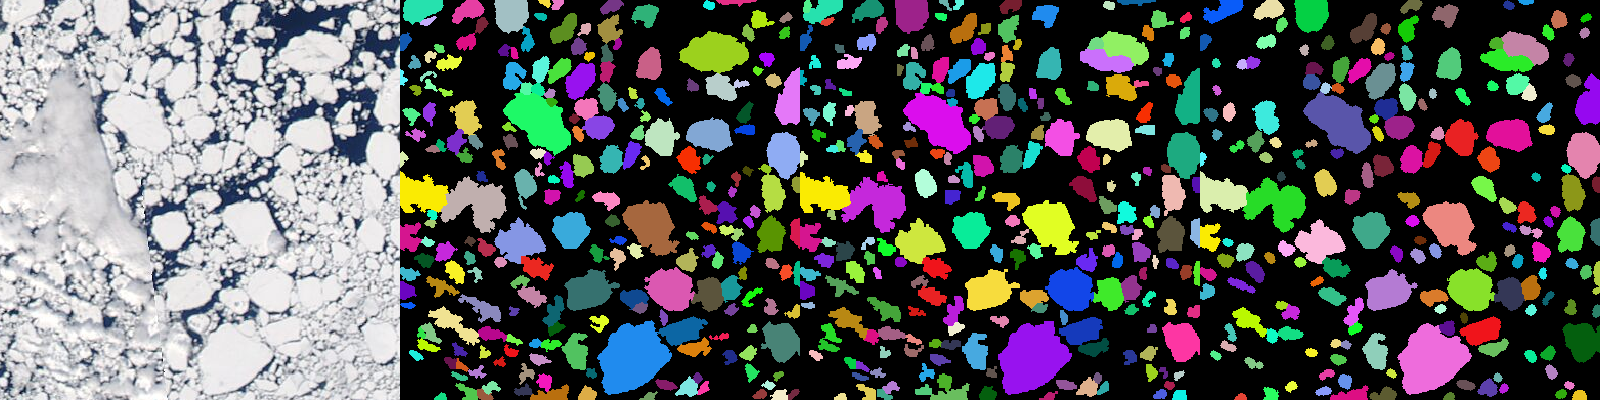

In [83]:
mosaicview(tc_imgs[idx], view_seg_random.(SegmentedImage.([tc_imgs[idx]], splits))..., nrow=1)

In [84]:
# CairoMakie.available_gradients()

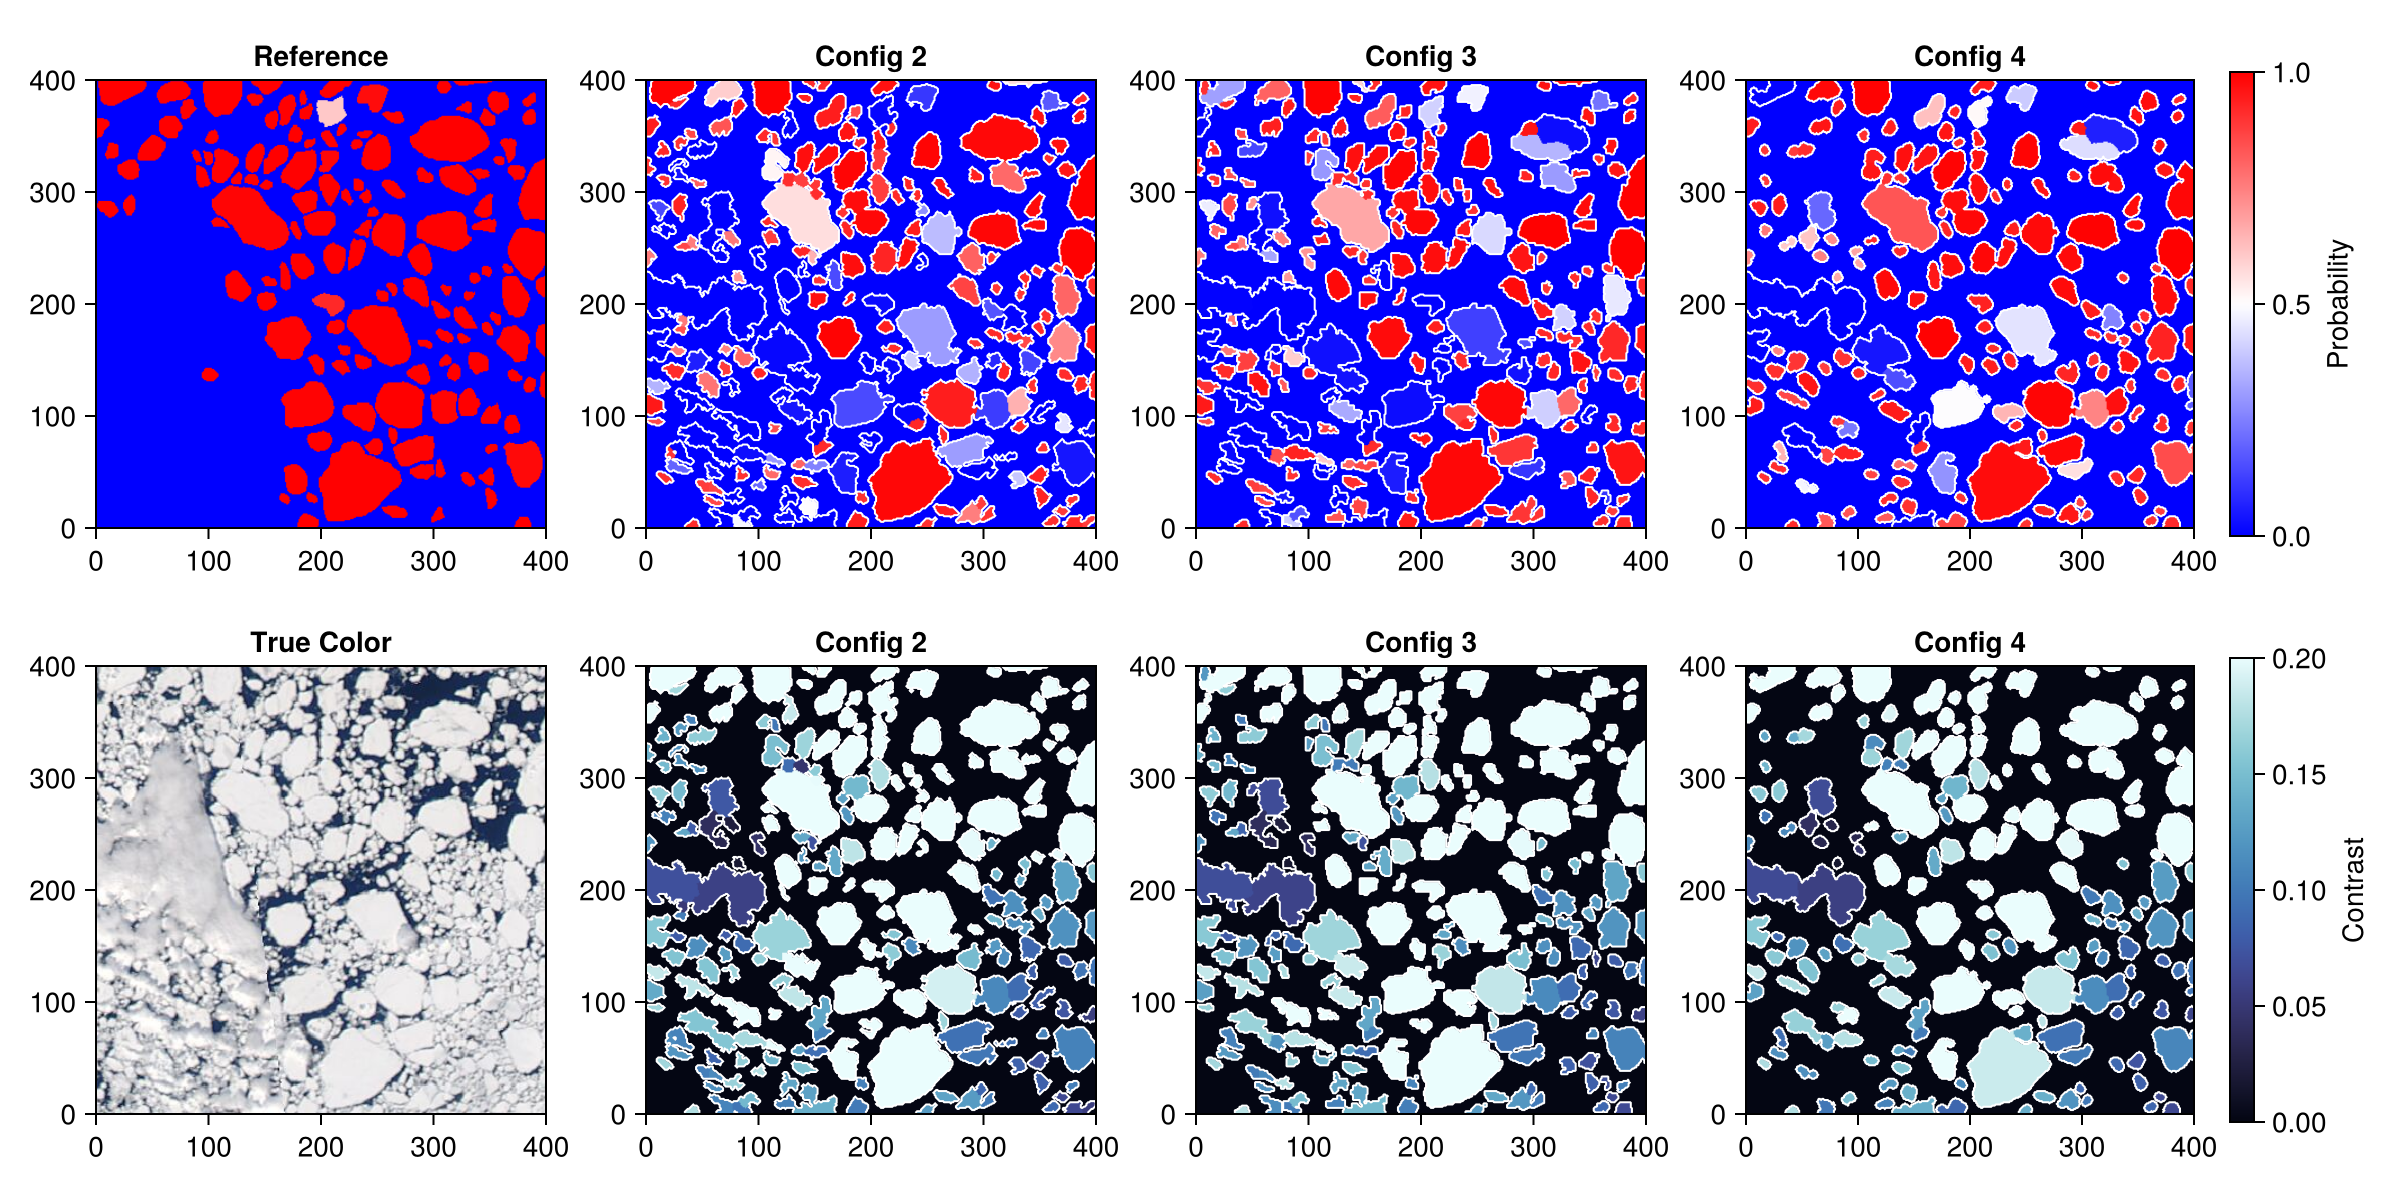

In [85]:
fig = Figure(size=(1200, 600))
ax = CairoMakie.Axis(fig[1, 1], aspect=1, title="Reference")
image!(ax, rotr90(true_floe_prob), colormap=:bwr)
    
for i in 2:4
    ax = CairoMakie.Axis(fig[1, i], aspect=1, title="Config "*string(i))
    global p = image!(ax, rotr90(prob_imgs[i - 1]), colormap=:bwr, colorrange=(0, 1))
    contour!(ax, rotr90(splits[i - 1] .> 0), levels=[0.5], color=:white)
end
Colorbar(fig[1, 5], p, label="Probability")
ax0 = CairoMakie.Axis(fig[2, 1], aspect=1, title="True Color")
image!(ax0, rotr90(tc_imgs[idx]))

for i in 2:4
    ax = CairoMakie.Axis(fig[2, i], aspect=1, title="Config "*string(i))
    global c = image!(ax, rotr90(contrast_imgs[i - 1]), colormap=:ice, colorrange=(0, 0.2))
    contour!(ax, rotr90(splits[i - 1] .> 0), levels=[0.5], color=:white)
end
Colorbar(fig[2, 5], c, label="Contrast")

fig

Merge floes function: accept a list of segmentation labels, 

Input: List of candidate segmentation results, associated falsecolor image, masks, coastal buffer.

1. Initialize with the first image in the list
2. While more images remain, grab the next image.
   1. Get the regionprops for the new image.
   2. Get a list of labels in the initial image to replace, and labels in the new image to insert
   3. If the lists aren't empty, merge the arrays and update the regionprops table

Chosing labels to replace: relevant sets let us see where there is agreement. The objects 

# Examine the residuals
- Regions of ice not classified by the merge floes algorithm may be present and detectable

In [111]:
init_img = splits[1]
comp_img = splits[3]
df1 = extended_regionprops_table(init_img, fc_imgs[idx], masks[idx])
df2 = extended_regionprops_table(comp_img, fc_imgs[idx], masks[idx])
df_comp = objectwise_compare_segmentation(df1, df2, init_img, comp_img);

within_tolerance(d, e) = (d .< 5) .&& (e .< 0.2)
df_matches = subset(df_comp, [:dist_s1_s2, :scaled_relative_error_area] => within_tolerance);

In [112]:
sort(combine(groupby(df_matches, :s2_label), nrow), :nrow);

## Visualizing the merge process


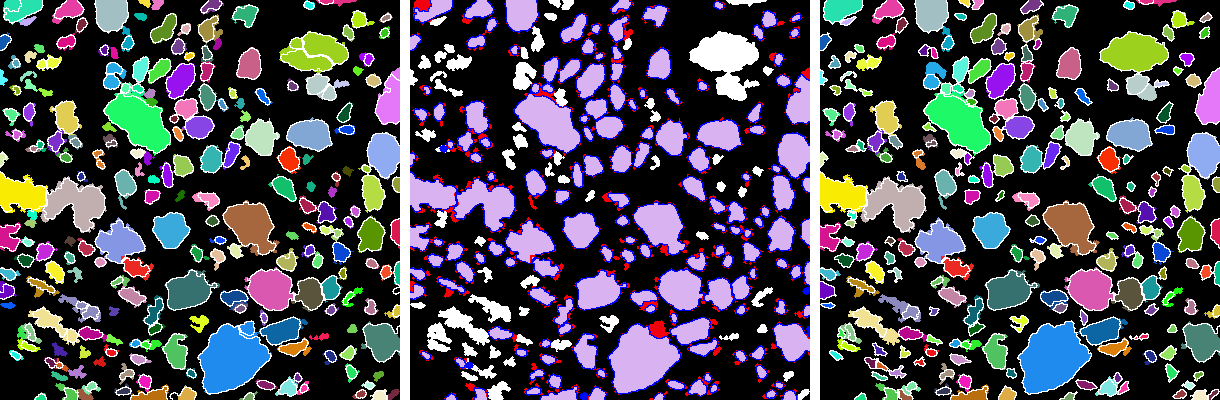

In [113]:
vsr(arr) = view_seg_random(SegmentedImage(tc_imgs[1], arr))

# panel 1
init_view = vsr(init_img)
comp_outlines = isboundary(comp_img)
init_view[comp_outlines .> 0] .= RGB(1, 1, 1)

# panel 2
init_selection = zeros(Int64, size(init_img))
comp_selection = copy(init_selection)

init_indices = component_indices(init_img)
comp_indices = component_indices(comp_img)

_assign_labels!(init_selection, init_indices, df_matches.s1_label)
_assign_labels!(comp_selection, comp_indices, df_matches.s2_label)
overlay_selection = RGB.(init_img .> 0)
overlay_selection[init_selection .> 0] .= RGB(0.95, 0, 0.05)
overlay_selection[comp_selection .> 0] .= RGB(0, 0.05, 0.95)
overlay_selection[comp_selection .> 0 .&& init_selection .> 0] .= RGB(0.85, 0.7, 0.95)
overlay_selection[isboundary(init_selection) .> 0] .= RGB(1, 0, 0)
overlay_selection[isboundary(comp_selection) .> 0] .= RGB(0, 0, 1)

# Update -> where there's a good match, replace the floe from 1 with the floe from 2
l1 = copy(init_img)
l2 = copy(comp_img)
merge_arrays!(l1, l2, df_comp)

overlay_merged = vsr(init_img)
outlines = isboundary(l1)
overlay_merged[outlines .> 0] .= RGB(1)

mosaicview(
    init_view, overlay_selection, overlay_merged, nrow=1, npad=10, fillvalue=RGB(1),
    )

#### Illustration
# Left: colors in the first set, white is the second
# Middle: Red is the first set, blue is the second, where they have a poor match is white
# Right: After basic merge

- panel 1: initial split, with outlines of next step overlaid
- panel 2: high-quality alignments. White = poor alignment, red = portion only in image 1, blue = portion only in image 2.
- panel 3: replace high-quality alignments (merge part 1)

Updating the merge step: we need a method for handling the poor alignments. It may still be that I need to do an all-or-nothing with the intersection -- if the area-average probability is better with the Set 2 result, then keep them all and discard anything with overlap greater than tolerance.

Merging rules
1. Keep floes with no conflicts
2. If there are conflicts, compare the bi-directional relevant sets, and keep the one with higher area-averaged probability


In [133]:
last(sort(df_comp, :s2_area), 15)[:, [:s1_label, :s2_label, :s1_area, :s2_area, :s1_min_row, :s1_min_col]]

Row,s1_label,s2_label,s1_area,s2_area,s1_min_row,s1_min_col
,Int64,Int64,Int64,Int64,Int64,Int64
1,354,189,1017,921,68,375
2,122,57,948,939,1,95
3,288,150,2011,987,32,280
4,186,90,1022,1018,213,153
5,344,181,1115,1113,322,362
6,290,143,1130,1117,118,287
7,351,187,1189,1178,133,367
8,123,58,1361,1305,218,95
9,5,4,1399,1308,172,1


In [132]:
df_comp[df_comp.s1_label .== 354, [:s1_probability, :s2_probability, :s2_area, :s1_area, :s1_solidity, :s2_solidity, :scaled_relative_error_area]]

Row,s1_probability,s2_probability,s2_area,s1_area,s1_solidity,s2_solidity,scaled_relative_error_area
,Float64,Float64,Int64,Int64,Float64,Float64,Float64
1,0.997097,0.986386,921,1017,1.0,0.985554,0.0495356


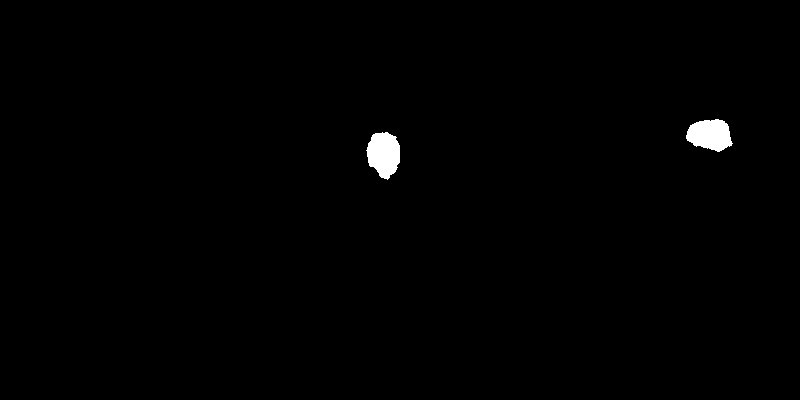

In [131]:
mosaicview(Gray.(splits[1] .== 351), Gray.(splits[3] .== 143), nrow=1)

In [ ]:
init_img = copy(splits[1])
for i in 1:length(splits)
    comp_img = splits[i]
    df1 = extended_regionprops(init_img, fc_imgs[idx], masks)
    df2 = extended_regionprops(comp_img, fc_imgs[idx], masks)
    df_comp = objectwise_compare_segmentation(df1, df2, init_img, comp_img);

    within_tolerance(d, e) = (d .< 5) .&& (e .< 0.2)
    df_matches = subset(df_comp, [:dist_s1_s2, :scaled_relative_error_area] => within_tolerance);
    merge_arrays!(init_img, comp_img, df_matches)
end

In [ ]:
mosaicview(vsr(splits[1]), vsr(splits[3]), vsr(init_img), nrow=1)

In [ ]:
outlines = (binary_floes[idx] .> 0) .- erode(binary_floes[idx] .> 0)
inclusion_likelihood = RGB.((sum(splits .|> r -> r .> 0) .+ binarized_imgs[idx])./ 5)
inclusion_likelihood[outlines .> 0] .= RGB(1, 0, 0)
cview_merged = vsr(init_img)
cview_merged[outlines .> 0] .= RGB(1, 1, 1)

residual = copy(binarized_imgs[idx])
residual[splits[1] .> 0] .= 0;

mosaicview(tc_imgs[idx], inclusion_likelihood, cview_merged, nrow=1)

In [ ]:
resid = view_seg_random(SegmentedImage(tc_imgs[1], 
        label_components(imfill(residual, (0, 1)))))
resid[outlines .> 0] .= RGB(1, 0, 0)
minisplit =  view_seg_random(SegmentedImage(tc_imgs[1], 
        dist_morph_split(imfill(residual, (0, 10)); max_depth=2,
        max_depth_ratio=0.8, opening_strel=strel_disk(1))))
minisplit[outlines .> 0] .= RGB(1, 0, 0)
mosaicview(resid, minisplit, nrow=1)


In [ ]:
include("../scripts/dev/segmentation.jl")

In [ ]:
dfs1 = extended_regionprops(
    splits[1], coastal_buffers[idx], classified_imgs[idx],  fc_imgs[idx])

Where I left off: 
* Need to set up merge algorithm which can take a stack of segmentation results
* Check whether the probability function has major errors in cloudy scenes
* Set strict rules for cloudy shapes

In [ ]:
# Of the training data, 93 contain at least 300 ice pixels
contains_ice = subset(train_cases.info, :ift_ice_fraction => r -> r .> 0);
no_ice = subset(train_cases.info, :ift_ice_fraction => r -> r .== 0);
nrow(contains_ice), nrow(no_ice)

In [ ]:
mosaicview(
    [tc_imgs[idx] for idx in high_ice_fraction.lookup_index]..., ncol=8)

In [ ]:
mosaicview(
    [tc_imgs[idx] for idx in no_ice.lookup_index]..., nrow=4)

In [ ]:
mosaicview(
    [view_seg_random(SegmentedImage(Gray.(blue.(fc_imgs[idx])), labels_map(segments[idx]))) for idx in no_ice.lookup_index]..., nrow=4)

# What to try
* k-means segmentation, determine which segment represents which surface types

In [ ]:
preproc_gray = Preprocess(histogram_params=(nbins=128, rblocks=2, cblocks=2, clip=1)).(tc_imgs, land_masks);
segments = kmeans_segmentation.(preproc_gray; k=4); # this function takes tiles too, with stitch clusters

In [ ]:
# add function view_classification() with preset colors
# (version of this is in the new pipeline branch)
mosaicview(
    [mosaicview(
            tc_imgs[idx],
            colorize_classification(classified_imgs[idx]),
            view_seg_random(segments[idx]), nrow=3) for idx in 1:5
    ]..., nrow=1)

In [ ]:
# approach: select the segments which have the highest proportions of the sea ice pixels.
idx = 110
masks = Dict(key => classified_imgs[idx] .== classifier.key[key] for key in keys(classifier.key));

In [ ]:
algo = IceDetectionBrightnessPeaksMODIS721(; band_7_max=0.2, possible_ice_threshold=0.5)
bright_ice_pixels = algo(fc_imgs[idx])

In [ ]:
cloud_fractions = segment_mean(SegmentedImage(masks["cloud"], labels_map(segments[idx])))
ice_fractions = segment_mean(SegmentedImage(Gray.(masks["ice"]), labels_map(segments[idx])))
bright_ice_fractions = segment_mean(SegmentedImage(bright_ice_pixels, labels_map(segments[idx])))
water_fractions = segment_mean(SegmentedImage(masks["water"], labels_map(segments[idx])))
mosaicview(tc_imgs[idx], view_seg(SegmentedImage(Gray.(masks["ice"]), labels_map(segments[idx]))), nrow=1)

In [ ]:
canny_edges = canny.(preproc_gray, [(Percentile(90), Percentile(5))], [1]);


In [ ]:
cviews = view_seg_random.(segments);

In [ ]:
idx = 70
overlay = copy(RGB.(cviews[idx]))
c_overlay = copy(RGB.(tc_imgs[idx]))
overlay[canny_edges[idx]] .= RGB(1, 0, 0)
c_overlay[canny_edges[idx]] .= RGB(1, 0, 0)
mosaicview(preproc_gray[idx], c_overlay, overlay, Gray.(canny_edges[idx]), nrow=1)


In [ ]:
imgs = []
for k in 1:4
    overlay = RGB.(labels_map(segments[idx]) .== k)
    overlay[canny_edges[idx]] .= RGB(1, 0, 0)
    push!(imgs, overlay)
end
mosaicview(imgs..., Gray.(canny_edges[idx]), nrow=3)


In [ ]:
background_segments = [s for s in keys(water_fractions) if water_fractions[s] > 0.3]

In [ ]:
mosaicview(Gray.(
        (labels_map(segments[idx]) .== 8) .|| (labels_map(segments[idx]) .== 6)), colorize_classification(classified_imgs[idx]), nrow=1)

In [ ]:
ice_segments = [s for s in keys(ice_fractions) if ice_fractions[s] > 0.3]

In [ ]:
band_1_mean = segment_mean(SegmentedImage(blue.(fc_imgs[idx]), labels_map(segments[idx])))


In [ ]:
# Segment with highest water fraction
mosaicview(Gray.(labels_map(segments[idx]) .== 3), colorize_classification(classified_imgs[idx]), nrow=1)

In [ ]:
ice_fractions

In [ ]:
# Segment with highest ice fraction: 2, followed by 1, then 4.
mosaicview([Gray.(labels_map(segments[idx]) .== ii) for ii in [1, 2, 3]]..., 
    colorize_classification(classified_imgs[idx]), nrow=1)


In [ ]:
cloud_fractions

In [ ]:
# Segment with highest cloud fraction: 4, followed by 1, then 2.
mosaicview([Gray.(labels_map(segments[idx]) .== ii) for ii in [5, 4, 2]]..., 
    colorize_classification(classified_imgs[idx]), nrow=1)


## Setting parameters based on the ice floes in the training dataset
1. Thresholds for the binarization algorithms. For the k-means algorithm, we have the bright floe detection; it includes the band 7 maximum and the band 1 minimum. 

In [ ]:
sea_ice_floe_cases = subset(coalesce.(train_cases.info, 0), :maximum_floe_size => r -> r .> 64);
df_list = []
for df_row in eachrow(sea_ice_floe_cases)
    idx = df_row.lookup_index
    img_indexmap = label_components(binary_floes[idx])
    img = SegmentedImage(fc_imgs[idx], img_indexmap)
    mean_colors = segment_mean(img)
    df = regionprops_table(img; properties=[:label, :bbox, :centroid, :area])
    df[:, :b7_mean] = [red(mean_colors[l]) for l in df[:, :label]]
    df[:, :b2_mean] = [green(mean_colors[l]) for l in df[:, :label]]
    df[:, :b1_mean] = [blue(mean_colors[l]) for l in df[:, :label]]
    df[:, :case_number] .= df_row.case_number

    areas = component_lengths(img_indexmap)
    perims = component_perimeters(img_indexmap)
    labels = intersect(keys(perims), filter(r -> r > 0, unique(img_indexmap)))
    circ = Dict(L => 4 * π * areas[L] / perims[L]^2 for L in labels)
    for l in df.label
        if l ∉ keys(circ)
            circ[l] = Missing
        end
    end
    cloud_fractions = segment_mean(SegmentedImage(cloud_masks[idx], img_indexmap))

    df[:, :circularity] = [circ[l] for l in df[:, :label]]
    df[:, :cloud_fraction] = [cloud_fractions[l] for l in df[:, :label]]
    push!(df_list, df)
end

df_all = vcat(df_list..., cols=:union);


In [ ]:
using CairoMakie

f = Figure(size=(700, 350))
ax1 = CairoMakie.Axis(f[1, 1], title="Floe-Average Reflectance",
    ylabel="Band 7 Reflectance", xlabel="Band 1 Reflectance",
    yticks=0:0.2:1, xticks=0:0.2:1, limits=(0, 1, 0, 1))

a = scatter!(ax1, df_all[:, :b1_mean], df_all[:, :b7_mean])

ax2 = CairoMakie.Axis(f[1, 2], title="Floe-Average Reflectance",
    ylabel="Band 7 Reflectance", xlabel="Band 2 Reflectance",
    yticks=0:0.2:1, xticks=0:0.2:1, limits=(0, 1, 0, 1))

a = scatter!(ax2, df_all[:, :b2_mean], df_all[:, :b7_mean], colormap=:viridis)

current_figure()


Nearly all the manually detected floes reflectance in Band 1 and Band 2 brighter than 0.6. For Band 1, the 5th percentile is 0.68, and for Band 2, the 5th percentile is 0.62. The minimum reflectance is used to decide which pixels are bright enough to possibly be ice floes, and the peak to the right of this value is used. So we set the minimum brightness, which applies to both bands, to 0.6.

## TODO items
* Separate clear-sky and cloudy ice floes
* 



In [ ]:
percentile(df_all[:, :b2_mean], 5), percentile(df_all[:, :b2_mean], 1)

In [ ]:
percentile(df_all[:, :b7_mean], 95), percentile(df_all[:, :b7_mean], 99)

# Calibrating the dist-morph-split function

* Run pre-proc and binarization first
* Label floes for the manual label set

In [ ]:
preproc_function = FSPipeline.Preprocess(
    diffusion_algorithm = PeronaMalikDiffusion(; λ=0.1, K=0.1, niters=5, g="exponential"),
    adapthisteq_params = (nbins=256, rblocks=2, cblocks=2, clip=5),
    unsharp_mask_params = (radius=50, amount=0.3, threshold=0.01),
)
tiles = get_tiles(tc_imgs[1], (400, 400)) # single tile
preproc_gray = preproc_function.(tc_imgs, land_masks, [tiles]);

In [ ]:
mosaicview(preproc_gray[1:10], nrow=2)

In [ ]:
# Workflows produce binary images
function kmeans_workflow(preproc_gray, fc_masked, water_mask, ice_mask, cloud_mask; k=4, cluster_selection_algorithm=cluster_algo)
    masked_gray = apply_landmask(preproc_gray, water_mask)
    kmeans_result = kmeans_binarization(
        masked_gray, fc_masked; k=k, cluster_selection_algorithm=cluster_algo) .> 0
    return kmeans_result
end

function adaptive_workflow(preproc_gray, land_mask, water_mask, ice_mask, cloud_mask; window_size=400, percentage=0)
    adaptive_result = binarize(preproc_gray, AdaptiveThreshold(; window_size=window_size, percentage=percentage)) .> 0
    apply_landmask!(adaptive_result, land_mask)
    apply_landmask!(adaptive_result, water_mask)
    return adaptive_result
end

In [ ]:
adaptive_bin = adaptive_workflow.(
    preproc_gray, land_masks, water_masks, ice_masks, cloud_masks; window_size=400);

In [ ]:
mosaicview(adaptive_bin[1:10] .|> r -> Gray.(r), nrow=2)

# Calibrating the distance threshold method
- select cases with floes to compare to
- measure of success - select relevant sets, compute recall/precision across these sets, and compute shape error metrics -- e.g. the relative error in area, and the distance with the boundaries. This is the crux of the segmentation method!

In [ ]:
split_labeled = dist_morph_split.(adaptive_bin;   
    max_depth=25, max_depth_ratio=0.5, max_expand=2, opening_strel=strel_disk(3));

# If these aren't removed, the rotation / shape difference stuff fails
remove_small_segments!.(split_labeled, 100);
remove_small_segments!.(manual_labeled, 100);

In [ ]:
# Included in the filter-floes function
function get_relevant_set(labels1, labels2)
    df1 = regionprops_table(labels1; properties=[:label, :area, :bbox, :centroid])
    df2 = regionprops_table(labels2; properties=[:label, :area, :bbox, :centroid])
    return get_relevant_set(df1, df2, labels1, labels2)
end

# This produces a set of dictionaries mapping labels from manual to automatic segments
df_list = get_relevant_set.(manual_labeled, split_labeled);

In [ ]:
import IceFloeTracker.Tracking: shape_difference

"""
Compute object-wise similarity metrics between two labels:
1. euclidean distance between centroids
2. relative error in area, perimeter, orientation
"""
function objectwise_comparison(indexmap1, indexmap2)
    
    properties = [:label, :centroid, :area, :bbox, :perimeter, :orientation]
    df_s1 = regionprops_table(indexmap1; properties=properties)
    df_s2 = regionprops_table(indexmap2; properties=properties)
    add_floemasks!(df_s1, indexmap1)
    add_floemasks!(df_s2, indexmap2)
    
    # This accounts for the centroid and bbox turning into col_ and row_ terms
    properties = Symbol.(names(df_s1))

    relevant_set = get_relevant_set(df_s1, df_s2, indexmap1, indexmap2)

    # Loop through the floes in the first indexmap (assumed to be the true labels)
    # and compute the similarity measures
    results = DataFrame[]
    for floe in eachrow(df_s1)
        
        g = floe.label
        
        sd(mask, orientation) = round(shape_difference(floe.mask, floe.orientation, mask, orientation); digits=3)
        
        g in keys(relevant_set) && begin
            df_rs = subset(df_s2, :label => ByRow(s -> s in relevant_set[g]))
            df_rs[:, :s1_label] .= g
            
            df_rs[:, :dist_s1_s2] = euclidean_distance(floe, df_rs; r=1) # r=1 means use pixel units, not meters

            # Relative errors
            transform!(df_rs, :area => ByRow(a -> (a - floe.area) / floe.area) => :relative_error_area)
            transform!(df_rs, :perimeter => ByRow(p -> (p - floe.perimeter) / floe.area) => :relative_error_perimeter)

            # Difference in orientation
            transform!(df_rs, :orientation => ByRow(o -> rem2pi(o - floe.orientation, RoundNearest)) => :error_orientation)
                
            # Shape difference
            transform!(df_rs, [:mask, :orientation] => ByRow(sd) => :shape_difference)
            push!(results, df_rs)
        end
    end
    length(results) == 0 && return nothing
    
    results_df = vcat(results...; cols=:union)
    rename!(results_df, Dict(r => Symbol("s2_", r) for r in properties))
    rename!(df_s1, Dict(r => Symbol("s1_", r) for r in properties))
    merged_results = outerjoin(df_s1, results_df; on=:s1_label)
    return merged_results[:, Not(:s2_mask, :s1_mask)]
end


## Visualization and measurements
Overlay images:
- Color-code the ground truth labels, the true positive and false positive from the segments
- Mark if in a relevant set 



In [ ]:
split_labeled = dist_morph_split.(adaptive_bin;   
    max_depth=25, max_depth_ratio=0.75, max_expand=2, opening_strel=strel_disk(5));

# If these aren't removed, the rotation / shape difference stuff fails
remove_small_segments!.(split_labeled, 100);

In [ ]:
idx = 1
function overlay_images(img, manual_labels, split_labels;
    manual_color = RGBA(1, 0.1, 0),
    auto_color = RGBA(1, 0.6, 0),
    tp_color = RGBA(0.4, 0.6, 1))
    boundaries = isboundary(split_labels)
    overlay_img = copy(img)
    overlay_img[manual_labels .> 0] .= manual_color
    overlay_img[split_labels .> 0] .= auto_color
    overlay_img[split_labels .> 0 .&& manual_labels .> 0] .= tp_color
    overlay_img[boundaries .> 0] .= RGBA(0.2, 0.2, 0)
    return overlay_img
end

In [ ]:
idx = 11
overlay_img = overlay_images(tc_imgs[idx], manual_labeled[idx], split_labeled[idx])
overlay_img

In [ ]:
idx = 1
# Red: shapes removed from the binarization before splitting
overlay_images(tc_imgs[idx], adaptive_bin[idx], split_labeled[idx])

In [ ]:
parameters = DataFrame(max_depth=Int64[],
                  max_depth_ratio=Float64[],
                  max_expand=Int64[],
                  opening_strel_radius=Int64[]
)

results = DataFrame(
    mean_dist_s1_s2 = Float64[],
    mean_relative_error_area = Float64[],
    mean_relative_error_perimeter = Float64[],
    mean_scaled_shape_difference = Float64[],
    std_dist_s1_s2 = Float64[],
    std_relative_error_area = Float64[],
    std_relative_error_perimeter = Float64[],
    std_scaled_shape_difference = Float64[]
    )
    
for md in 15:5:25
    for mdr in [0.25, 0.5, 0.75]
        for me in [2, 3]
            for r in 1:5
                push!(parameters, [md, mdr, me, r])
            end
        end
    end
end

In [ ]:
train_set_labels = [r for r in manual_labeled if maximum(r) != 0];
train_set_binary = [a for (a, r) in zip(adaptive_bin, manual_labeled) if maximum(r) != 0];


In [ ]:
@time begin
for data in eachrow(parameters)
    split_labeled = dist_morph_split.(
        train_set_binary;   
        max_depth=data.max_depth,
        max_depth_ratio=data.max_depth_ratio,
        max_expand=data.max_expand,
        opening_strel=strel_disk(data.opening_strel_radius)
    )
    remove_small_segments!.(split_labeled, 100)
    df_comp = objectwise_comparison.(train_set_labels, split_labeled)
    df_all = vcat([d for d in df_comp if !isnothing(d)]...; cols=:union);
    df_all[:, :scaled_shape_difference] = df_all[:, :shape_difference] ./ df_all[:, :s1_area];
    results_mean = mean.(skipmissing.(eachcol(df_all[:, [:dist_s1_s2, :relative_error_area, :relative_error_perimeter, :scaled_shape_difference]])))
    results_std = std.(skipmissing.(eachcol(df_all[:, [:dist_s1_s2, :relative_error_area, :relative_error_perimeter, :scaled_shape_difference]])))
    push!(results, vcat(results_mean, results_std))
end    
end
nothing

In [ ]:
# save both of these outputs!
# Note that these are global results, so we won't know yet if there's a difference with cloudy scenes vs clear sky, for example

In [ ]:
save("../data/parameter_sweep_results.csv", results)

In [ ]:
save("../data/parameter_sweep_parameter_list.csv", results)

In [ ]:
results[:, :max_expand] = parameters[1:9, :max_expand]
results

In [ ]:
results_df = hcat(parameters, results);
save("../data/parameter_sweep_dist_morph_split.csv", results_df)

In [ ]:
# , max_expand	opening_strel_radius
f = CairoMakie.Figure(size=(1000, 400))
for (row, metric_set) in zip(1:2, 
        [[:mean_relative_error_area, :mean_relative_error_perimeter],
         [:mean_dist_s1_s2,:mean_scaled_shape_difference]])
    for (col, par) in zip(1:4, names(parameters))
        ax = CairoMakie.Axis(f[row,col], xlabel=string(par), ylabel="Error", aspect=1)
        for (color, metric) in zip([:orange, :blue], metric_set)
            scatter!(ax, results_df[:, par], results_df[:, metric]; label=String(metric), color=color)
        end
        Legend(f[row, 5], ax; tellheight=false, tellwidth=true) #, halign=:right, valign=:bottom, margin=(5, 5, 5, 5))
    end
end

f

In [ ]:
combine(groupby(results_df, :opening_strel_radius), 
    [:mean_relative_error_area, :mean_relative_error_perimeter, :mean_dist_s1_s2, :mean_scaled_shape_difference] .=> mean)

The results above show the mean error across all the images. They do not show any effects of size, and they do not show any effects of omission. E.g. if an increase in a parameter led to less floes being retained, but the retained floes are higher quality, then that increase in errors of omission is not included.

`max_depth` controls the maximum distance from background pixels for the threshold selection. In the aggregate, we see only weak improvement, likely insignificant, going from 15 to 25 pixels. We may see differences with lower max-depth thresholds, though, and the results may be different for large floes than for small floes.

`max_depth_ratio` sets the limit for the maximum distance function. Only thresholds up to the max depth times the max depth ratio are considered. Increasing the max depth ratio from 0.25 to 0.75 massively improves the results: relative error in the area drops from 10 to 3, relative error in perimeter from 0.8 to 0.2, centroid distance from 15 to 8 pixels, and scaled dhape difference from 10 to 3. Standard deviation of each measure decreases, as well. 

`max_expand` sets the amount to expand the labels, which is intended to re-fill a region up to a limit. The results are only slightly sensitive to this parameter, with slightly better performance at max expand = 2 than at 3.

`opening_strel_radius` is used to clean up each layer before adding it to the stack. The error metrics generally improve from radius 1 to 5; I suspect the higher radii are removing a lot of floes from the image.

The calculation across all permutations was slow, so we don't want to repeat that. For the next step, we want to check the effects of the max depth ratio and opening strel radius as a function of floe size. In this experiment, we keep the object-wise measures so that we can check for under/oversegmentation error.

In [ ]:
@time begin
    parameters = DataFrame(max_depth=Int64[],
                      max_depth_ratio=Float64[],
                      max_expand=Int64[],
                      opening_strel_radius=Int64[]
    )
    
    results = []        
    for md in [5, 15, 25]
        for mdr in [0.5, 0.625, 0.75]
            for me in [2]
                for r in 1:5
                    push!(parameters, [md, mdr, me, r])
                end
            end
        end
    end
    
    for data in eachrow(parameters)
        split_labeled = dist_morph_split.(
            train_set_binary;   
            max_depth=data.max_depth,
            max_depth_ratio=data.max_depth_ratio,
            max_expand=data.max_expand,
            opening_strel=strel_disk(data.opening_strel_radius)
        )
        remove_small_segments!.(split_labeled, 100)
        df_comp = objectwise_comparison.(train_set_labels, split_labeled)
        for idx in 1:length(df_comp)
            if !isnothing(df_comp[idx])
                df_comp[idx][:, :lookup_index] .= idx
            end    
        end
        
        df_all = vcat([d for d in df_comp if !isnothing(d)]...; cols=:union);
        df_all[:, :scaled_shape_difference] = df_all[:, :shape_difference] ./ df_all[:, :s1_area];        
        push!(results, df_all)
    end    
end
nothing

In [ ]:
for idx in range(1, length(results))
    results[idx][:, :parameter_index] .= idx
end

df_test = vcat(results...; cols=:union);

In [ ]:
save("../data/parameter_sweep_parameter_list_exp2.csv", parameters)
save("../data/parameter_sweep_dist_morph_split_test2.csv", df_test)

In [ ]:
f = CairoMakie.Figure()
ax1 = CairoMakie.Axis(f[1,1], xlabel="Centroid Distance")
hist!(ax1, filter(r -> !ismissing(r), df_test[df_test.parameter_index .== 1, :dist_s1_s2]), bins=1:50)
ax2 = CairoMakie.Axis(f[1,2], xlabel="Area Relative Error")
hist!(ax2, filter(r -> !ismissing(r), df_test[df_test.parameter_index .== 1, :relative_error_area]), bins=1:2:100)
ax3 = CairoMakie.Axis(f[1,3], xlabel="Shape Difference")
hist!(ax3, filter(r -> !ismissing(r), df_test[df_test.parameter_index .== 1, :shape_difference]), bins=1:20:1000)

hist!(ax1, filter(r -> !ismissing(r), df_test[df_test.parameter_index .== 5, :dist_s1_s2]), bins=1:50, color=(:red, 0.5))
hist!(ax2, filter(r -> !ismissing(r), df_test[df_test.parameter_index .== 5, :relative_error_area]), bins=1:2:100, color=(:red, 0.5))
hist!(ax3, filter(r -> !ismissing(r), df_test[df_test.parameter_index .== 5, :shape_difference]), bins=1:20:1000, color=(:red, 0.5))


f

# Where I'm leaving off:
Look at the values per setting, and check things like the number of floes, the number of floes per relevant set, and any area dependence of the results.

Also need to check whether the splitting function gives similar results for tuning with the other binarization routines.

In [ ]:
scatter(df_test[df_test.parameter_index .== 1, :s1_area],
    df_test[df_test.parameter_index .== 1, :dist_s1_s2])
scatter!(df_test[df_test.parameter_index .== 5, :s1_area],
    df_test[df_test.parameter_index .== 5, :dist_s1_s2])
current_figure()

In [ ]:
df_comp[1].dist_s1_s2

In [ ]:
view_seg(SegmentedImage(Gray.(cloud_masks[idx]), label_components(adaptive_bin[idx])))

In [ ]:
idx = 5
overlay_img = overlay_images(tc_imgs[idx], manual_labeled[idx], split_labeled[idx])
overlay_img

In [ ]:
regionprops_table(split_labeled[idx])

In [ ]:
length(tc_imgs)

In [ ]:
mosaicview(
    [overlay_images(tc_imgs[idx], manual_labeled[idx], split_labeled[idx]) for idx in 1:20]..., nrow=4)

In [ ]:
mosaicview(
    [overlay_images(tc_imgs[idx], manual_labeled[idx], split_labeled[idx]) for idx in 21:40]..., nrow=4)

In [ ]:
mosaicview(
    [overlay_images(tc_imgs[idx], manual_labeled[idx], split_labeled[idx]) for idx in 41:60]..., nrow=4)

In [ ]:
mosaicview(
    [overlay_images(tc_imgs[idx], manual_labeled[idx], split_labeled[idx]) for idx in 61:80]..., nrow=4)

In [ ]:
mosaicview(
    [overlay_images(tc_imgs[idx], manual_labeled[idx], split_labeled[idx]) for idx in 81:100]..., nrow=4)

In [ ]:
mosaicview(
    view_seg_random.(
        SegmentedImage.(
            tc_imgs[1:20], split_labeled[1:20]))..., nrow=4)

In [ ]:
bf = FSPipeline.clean_binary_floes(adapt[6], ice_masks[6], cloud_masks[6])
max_hole_fill=2000
max_distance=5
max_expand=3
opening_strel=strel_disk(3)

dist = distance_transform(feature_transform(.!bf))
levels = Dict(0 => label_components(opening(dist .> 0, opening_strel))) # Initialize with one run of opening
### Build pyramid - each size is the opened and filled thresholded image
for dist_threshold in 0:max_distance
    markers = opening(dist .> dist_threshold, opening_strel)
    markers .= .!imfill(.!markers, (0, max_hole_fill))
    levels[dist_threshold] = label_components(markers)
end
final_labels = deepcopy(levels[max_distance])

### Descend pyramid
for dist_threshold in max_distance:-1:1
    # Get indices from level d-1
    indices = component_indices(levels[dist_threshold - 1])

    # Expand indices at level d
    expanded = expand_labels(levels[dist_threshold], max_expand)
    for L in keys(indices)
        (L <= 0) && continue

        matched_labels = unique(levels[dist_threshold][indices[L]])

        # If intersection of the label at level
        if (0 ∈ matched_labels) && (length(matched_labels) <= 2)
            final_labels[indices[L]] .= L
            continue
        end
        # Otherwise, expand the current level, and set the next level down to the expanded indices.
        # May need to check the number of matched labels in the expanded image.
        levels[dist_threshold - 1][indices[L]] .= expanded[indices[L]]
        final_labels[indices[L]] .= expanded[indices[L]]
    end
end

In [ ]:
f = Figure(size=(1200, 300))
ax1 = CairoMakie.Axis(f[1, 1], title="Binary Image", aspect=1)
ax2 = CairoMakie.Axis(f[1, 2], title="Distance Function", aspect=1)
ax3 = CairoMakie.Axis(f[1, 3], title="Level 5", aspect=1)
ax4 = CairoMakie.Axis(f[1, 4], title="Level 3", aspect=1)
image!(ax1, rotr90(bf))
contourf!(ax2, rotr90(dist), levels=10)

level_1 = view_seg_random(SegmentedImage(Gray.(bf), levels[1]))



level_5 = view_seg_random(SegmentedImage(Gray.(bf), levels[5]))
level_5_overlay = RGB.(bf .> 0)
level_5_overlay[levels[5] .> 0] .= level_5[levels[5] .> 0]

image!(ax3, rotr90(level_5_overlay))

level_3 = view_seg_random(SegmentedImage(Gray.(bf), levels[3]))
level_3_overlay = RGB.(bf .> 0)
level_3_overlay[levels[3] .> 0] .= level_3[levels[3] .> 0]

image!(ax4, rotr90(level_3_overlay))

final = view_seg_random(SegmentedImage(Gray.(bf), final_labels))

current_figure()

In [ ]:
# Computes the confusion matrix as a 1 row dataframe for all non-masked pixels
function confusion_matrix(ground_truth, predicted, mask)
    tp = sum(ground_truth .&& predicted .&& .! mask)
    fp = sum(.!ground_truth .&& predicted .&& .! mask)
    tn = sum(.!ground_truth .&& .!predicted .&& .! mask)
    fn = sum(ground_truth .&& .!predicted .&& .! mask)
    n = sum( .! mask)
    r = sum(predicted)
    return DataFrame(tp=tp, fp=fp, tn=tn, fn=fn, n=n, r=r)
end


# Comparing the segmentation results to the data
* The "Segment" function computes the segmentation for each of the processed images; we can test the sensitivity for preprocessing by altering the "preproc_gray" vector
* The regionprops table can be broadcasted without an issue. I'm having it take in the orientation, axis lengths, areas, etc.
* In the paper

In [ ]:
vsr(r) = view_seg_random(SegmentedImage(Gray.(r .> 0), r))


In [ ]:

function objectwise_compare_segmentation(
    df1, df2, labels1, labels2, cloud_mask
)    
    properties = union(propertynames(df1), propertynames(df2))
    relevant_set = get_relevant_set(df1, df2, labels1, labels2)
    results = DataFrame[]
    for floe in eachrow(df1)
        g = floe.label
        gtmask = labels1 .== g
        
        cloud_fraction = mean(cloud_mask[gtmask])
        g in keys(relevant_set) && begin
            df_rs = subset(df2, :label => ByRow(s -> s in relevant_set[g]))
            df_rs[:, :dist_s1_s2] = euclidean_distance(floe, df_rs; r=1) # r=1 means use pixel units, not meters
            df_rs[:, :scaled_relative_error_area] =
                abs.(df_rs.area .- floe.area) ./ (df_rs.area .+ floe.area)
            df_rs[:, :relative_error_area] =
                (df_rs.area .- floe.area) ./ floe.area

            # object-wise precision and recall
            
            pr = []
            re = []
            sd = []
            for s in df_rs.label
                smask = labels2 .== s
                intersect_area = sum(gtmask .&& smask)
                push!(pr, intersect_area / sum(smask))
                push!(re, intersect_area / sum(gtmask))
                push!(sd, sum(gtmask .|| smask) .- intersect_area)
            end
            df_rs[:, :precision] .= pr
            df_rs[:, :recall] .= re
            df_rs[:, :shape_difference] .= sd
            
            for colname in properties
                df_rs[!, Symbol("s1_", colname)] .= floe[colname]
            end
            df_rs[!, :s1_cloud_fraction] .= cloud_fraction
            
            push!(results, df_rs)
        end
    end
    if length(results) == 0
        return DataFrame(Dict(x=>[] for x in [:s1_label, :s2_label, :dist_s1_s2, :scaled_relative_error_area]))
    end
    results_df = vcat(results...; cols=:union)
    rename!(results_df, Dict(r => Symbol("s2_", r) for r in properties))

    return results_df
end



In [ ]:
labeled_floes = label_components.(binary_floes)
dfs_gt = regionprops_table.(labeled_floes; properties=[:label, :area, :bbox, :centroid, :perimeter, :orientation, :major_axis_length, :minor_axis_length])

In [ ]:
@time begin
    # First run was with clip=5
    # Running now with clip=1
    preproc_function = FSPipeline.Preprocess(
        diffusion_algorithm = PeronaMalikDiffusion(; λ=0.1, K=0.1, niters=7, g="exponential"),
        adapthisteq_params = (nbins=128, rblocks=2, cblocks=2, clip=5),
        unsharp_mask_params = (radius=50, amount=0.3, threshold=0.01),
    )
    tiles = get_tiles(tc_imgs[1], (400, 400)) # single tile
    preproc_gray = preproc_function.(tc_imgs, land_masks, [tiles]);
    segmented_imgs = Segment.(preproc_gray, fc_masked, ice_masks, land_masks, coastal_buffers, cloud_masks);
end

In [ ]:
dfs_segments = regionprops_table.(segmented_imgs; properties=[:label, :area, :bbox, :centroid, :perimeter, :orientation, :major_axis_length, :minor_axis_length]);
df_comps = objectwise_compare_segmentation.(dfs_gt, dfs_segments, labeled_floes, segmented_imgs, cloud_masks);

In [ ]:
df_all = vcat(df_comps...; cols=:union);
df_all[:, :cloudy] = df_all[:, :s1_cloud_fraction] .> 0.5
df_all[:, :length_scale] = df_all[:, :s1_area] .^ 0.5 .* 0.25; # sqrt then convert to km
df_all[:, :scaled_shape_difference] .= df_all[:, :shape_difference] ./ df_all[:, :s1_area]
df_all[:, :orientation_diff_s1_s2] = df_all[:, :s1_orientation] .- df_all[:, :s2_orientation];

In [ ]:
vars = [:precision, :recall, :relative_error_area, :scaled_shape_difference, :orientation_diff_s1_s2]
combine(groupby(df_all, :cloudy), vars .=> std)

In [ ]:
vars = [:precision, :recall, :relative_error_area, :scaled_shape_difference, :orientation_diff_s1_s2]
combine(groupby(df_all, :cloudy), vars .=> mean)

In [ ]:
vars = [:precision, :recall, :relative_error_area, :scaled_shape_difference, :orientation_diff_s1_s2]
combine(groupby(df_all, :cloudy), vars .=> median)

In [ ]:
using CairoMakie

f = Figure(size=(1200, 800))
ax = CairoMakie.Axis(f[1,1], title="Centroid (Row)", aspect=1)
for idx in 1:length(df_comps)
    if nrow(df_comps[idx]) > 0
        scatter!(ax, df_comps[idx].s1_row_centroid, df_comps[idx].s2_row_centroid, color=:black, markersize=3)
    end
end
ax = CairoMakie.Axis(f[1,2], title="Centroid (Col)", aspect=1)
for idx in 1:length(df_comps)
    if nrow(df_comps[idx]) > 0
        scatter!(ax, df_comps[idx].s1_col_centroid, df_comps[idx].s2_col_centroid, color=:black, markersize=3)
    end
end

ax = CairoMakie.Axis(f[1,3], title="Major Axis Length", aspect=1)
for idx in 1:length(df_comps)
    if nrow(df_comps[idx]) > 0
        scatter!(ax, df_comps[idx].s1_major_axis_length, df_comps[idx].s2_major_axis_length, color=:black, markersize=3)
    end
end

ax = CairoMakie.Axis(f[1,4], title="Minor Axis Length", aspect=1)
for idx in 1:length(df_comps)
    if nrow(df_comps[idx]) > 0
        scatter!(ax, df_comps[idx].s1_minor_axis_length, df_comps[idx].s2_minor_axis_length, color=:black, markersize=3)
    end
end

ax = CairoMakie.Axis(f[2,1], title="Orientation", aspect=1)
for idx in 1:length(df_comps)
    if nrow(df_comps[idx]) > 0
        scatter!(ax, df_comps[idx].s1_orientation, df_comps[idx].s2_orientation, color=:black, markersize=3)
    end
end

ax = CairoMakie.Axis(f[2,2], title="Length Scale", aspect=1)
for idx in 1:length(df_comps)
    if nrow(df_comps[idx]) > 0
        scatter!(ax, df_comps[idx].s1_area .^ 0.5, df_comps[idx].s2_area .^ 0.5, color=:black, markersize=3)
    end
end


ax = CairoMakie.Axis(f[2,3], title="Object-wise precision", aspect=1)
for idx in 1:length(df_comps)
    if nrow(df_comps[idx]) > 0
        length_scale = df_comps[idx].s1_area .^ 0.5
        scatter!(ax, length_scale, df_comps[idx].precision, color=:black, markersize=3)
    end
end


ax = CairoMakie.Axis(f[2,4], title="Area Scaled Error", aspect=1, limits=(0, 150, -1, 3), xlabel="Centroid Distance", ylabel="Error Area")
for idx in 1:length(df_comps)
    if nrow(df_comps[idx]) > 0
        length_scale = df_comps[idx].s1_area .^ 0.5
        scatter!(ax, df_comps[idx].dist_s1_s2, df_comps[idx].relative_error_area, color=:black, markersize=3)
    end
end

f

In [ ]:
f = Figure(size=(1000, 600))
ax1 = CairoMakie.Axis(f[1,1], xlabel="Centroid Distance (km)", ylabel="Count")
ax2 = CairoMakie.Axis(f[1,2], xlabel="Object-Wise Precision", ylabel="Count")
ax3 = CairoMakie.Axis(f[1,3], xlabel="Object-Wise Recall", ylabel="Count")
ax4 = CairoMakie.Axis(f[2,1], xlabel="Relative Area Difference (%)", ylabel="Count")
ax5 = CairoMakie.Axis(f[2,2], xlabel="Shape Difference / Length Scale", ylabel="Count")
ax6 = CairoMakie.Axis(f[2,3], xlabel="Orientation Difference", ylabel="Count")
axis_returns = []
for (grouping, color) in zip([df_all.s1_cloud_fraction .< 0.5, df_all.s1_cloud_fraction .>= 0.5], 
                              [(:blue, 0.5), (:red, 0.5)])
    begin
        a = hist!(ax1, df_all[grouping, :dist_s1_s2] .* 0.25, bins=0:0.25:10, color=color, normalization=:pdf)
        hist!(ax2, df_all[grouping, :precision], bins=0:0.05:1, color=color, normalization=:pdf)
        hist!(ax3, df_all[grouping, :recall], bins=0:0.05:1, color=color, normalization=:pdf)
        hist!(ax4, df_all[grouping, :relative_error_area] .* 100, bins=-100:5:100, color=color, normalization=:pdf)
        hist!(ax5, df_all[grouping, :shape_difference] ./ df_all[grouping, :length_scale], bins=0:3:100, color=color, normalization=:pdf)
        hist!(ax6, df_all[grouping, :orientation_diff_s1_s2], bins=-3:0.2:3, color=color, normalization=:pdf)
        push!(axis_returns, a)
    end   
end
CairoMakie.axislegend(ax1, axis_returns, ["Clear-sky", "Cloudy"], position=:rt)
f

In [ ]:
f = Figure(size=(1000, 600))
ax1 = CairoMakie.Axis(f[1,1], ylabel="Centroid Distance (km)", xlabel="Length Scale", limits=(0, 40, 0, 40))
ax2 = CairoMakie.Axis(f[1,2], ylabel="Object-Wise Precision", xlabel="Length Scale", limits=(0, 40, 0, 1))
ax3 = CairoMakie.Axis(f[1,3], ylabel="Object-Wise Recall", xlabel="Length Scale", limits=(0, 40, 0, 1))
ax4 = CairoMakie.Axis(f[2,1], ylabel="Relative Area Difference (%)", xlabel="Length Scale", limits=(0, 40, -100, 100))
ax5 = CairoMakie.Axis(f[2,2], ylabel="Shape Difference / Area", xlabel="Length Scale", limits=(0, 40, 0, 2))
ax6 = CairoMakie.Axis(f[2,3], ylabel="Orientation Difference", xlabel="Length Scale", limits=(0, 40, -3, 3))
axis_returns = []
for (grouping, color) in zip([df_all.s1_cloud_fraction .< 0.5, df_all.s1_cloud_fraction .>= 0.5], 
                              [(:blue, 0.5), (:red, 0.5)])
    begin
        a = scatter!(ax1, df_all[grouping, :length_scale], df_all[grouping, :dist_s1_s2] .* 0.25, color=color)
        scatter!(ax2, df_all[grouping, :length_scale],  df_all[grouping, :precision], color=color)
        scatter!(ax3, df_all[grouping, :length_scale], df_all[grouping, :recall], color=color)
        scatter!(ax4, df_all[grouping, :length_scale], df_all[grouping, :relative_error_area] .* 100, color=color)
        scatter!(ax5, df_all[grouping, :length_scale], df_all[grouping, :scaled_shape_difference], color=color)
        scatter!(ax6, df_all[grouping, :length_scale], df_all[grouping, :orientation_diff_s1_s2], color=color)
        push!(axis_returns, a)
    end   
end
CairoMakie.axislegend(ax1, axis_returns, ["Clear-sky", "Cloudy"], position=:rt)
f

In [ ]:
vars = [:precision, :recall, :relative_error_area, :shape_difference, :orientation_diff_s1_s2]
combine(groupby(df_all, :cloudy), vars .=> mean)

In [ ]:
vars = [:precision, :recall, :relative_error_area, :shape_difference, :orientation_diff_s1_s2]
combine(groupby(df_all, :cloudy), vars .=> median)

# Visualize segmentation results: comparison with manual labels

In [ ]:
tc_imgs[20:30]

In [ ]:
# question: filter floes for the labeled floes?
# Which clipping parameter to use?
overlay_imgs = []
for idx in [6, 10, 11, 12, 29, 72]    
    overlay = RGB.(zeros(size(binary_floes[idx])))
    overlay[binary_floes[idx] .> 0] .= RGB.(0, 0.6, 0.8)
    overlay[segmented_imgs[idx] .> 0] .= RGB(1, 0.4, 0.4)    
    overlay[binary_floes[idx] .> 0 .&& segmented_imgs[idx] .> 0] .= RGB.(0.9, 0.8, 0.4)
    
    push!(overlay_imgs, mosaicview(tc_imgs[idx], overlay, nrow=2, rowmajor=true, npad=10, fillvalue=RGBA(0,0,0,0)))
end
mosaicview(overlay_imgs..., nrow=1, npad=10, fillvalue=RGBA(0,0,0,0))

# TO DO
* It looks like the results differ from what I had earlier, why? Is it a difference in the clipping parameter or diffusion?
* Remove the floes that are below the size limit set in the algorithm. Note that there are some cases where the true floes are ambiguous, so the shapes in the segmented image may be real.
* Sort the cases to get a better idea of the difference in performance scene to scene
* 

In [ ]:
# question: filter floes for the labeled floes?
# Which clipping parameter to use?
overlay_imgs = []
for idx in [80, 81, 82, 83, 84]    
    overlay = RGB.(zeros(size(binary_floes[idx])))
    overlay[binary_floes[idx] .> 0] .= RGB.(0, 0.6, 0.8)
    overlay[segmented_imgs[idx] .> 0] .= RGB(1, 0.4, 0.4)    
    overlay[binary_floes[idx] .> 0 .&& segmented_imgs[idx] .> 0] .= RGB.(0.9, 0.8, 0.4)
    
    push!(overlay_imgs, mosaicview(tc_imgs[idx], overlay, nrow=2, rowmajor=true, npad=10, fillvalue=RGBA(0,0,0,0)))
end
mosaicview(overlay_imgs..., nrow=1, npad=10, fillvalue=RGBA(0,0,0,0))

In [ ]:
overlay_imgs = []
for idx in [6, 11, 12, 46, 72]
    
    overlay = RGB.(zeros(size(binary_floes[idx])))
    overlay[binary_floes[idx] .> 0] .= RGB.(0, 0.6, 0.8)
    overlay[segmented_imgs[idx] .> 0] .= RGB(1, 0.4, 0.4)    
    overlay[binary_floes[idx] .> 0 .&& segmented_imgs[idx] .> 0] .= RGB.(0.9, 0.8, 0.4)
    
    push!(overlay_imgs, mosaicview(tc_imgs[idx], overlay, nrow=2, rowmajor=true, npad=10, fillvalue=RGBA(0,0,0,0)))
end
mosaicview(overlay_imgs..., nrow=1, npad=10, fillvalue=RGBA(0,0,0,0))

Notes: 
* x is the ground truth in these plots
* Centroid should be close, since we're only do comparisons for the ones within the relevant set.
* However sizes can very different, and we also are including cases where the relevant set has multiple objects

Simon would like to have 


# Floe splitting and filtering calibration
The floe filtering is clearly too aggressive. We're losing a lot of the decently good ice floes. So, we need to look at objectwise properties after the dist morph split, and see what separates outliers from the good floes. That way we can select the settings that keep the good floes.

For the dist morph split, we have parameters for the minimm floe size, the largest hole to fill, and more importantly, the largest distance, the maximum expansion radius, and the structuring element.

In [ ]:
?FSPipeline.dist_morph_split

In [ ]:
# should filter floes first?
@time begin
    kbin_split = FSPipeline.dist_morph_split.(kbin_cleaned)
    abin_split = FSPipeline.dist_morph_split.(abin_cleaned)
end

In [ ]:
mosaicview(kbin_split[10:20] .|> r -> view_seg_random(SegmentedImage(Gray.(r .> 0), r)), nrow=2)

In [ ]:
mosaicview(abin_split[10:20] .|> r -> view_seg_random(SegmentedImage(Gray.(r .> 0), r)), nrow=2)

Plan: Start from the floe-filter section. Identify the thresholds for floes in the validation dataset, by grouping the observed data by cloud cover and checking the sizes, circularities, and the brightness. This gives us a baseline for the filters, and I can check whether it is working.

Next, look at the sensitivity of the split floes method to choices in depth and structuring elements. Investigate the quality of the floes shapes using object-wise analysis. Location, shape difference, boundary difference.

With those settings in place, look at the difference in object-wise properties from the good matches and all the many false positives. Are there additional features that would let us remove more false positives?

Finally, with the best-performing filter and splitting functions, test sensitivity to the preprocessing in the pipeline.

In [ ]:
kbin_split_pre = deepcopy(kbin_split)
abin_split_pre = deepcopy(abin_split)

# kbin_split = deepcopy(kbin_split_pre)
# abin_split = deepcopy(abin_split_pre)

FSPipeline.filter_floes!.(
        kbin_split,
        coastal_buffers,
        cloud_masks,
        fc_imgs;
        min_floe_size=64,
        min_cloudy_floe_size=300,
    )
FSPipeline.filter_floes!.(
        abin_split,
        coastal_buffers,
        cloud_masks,
        fc_imgs;
        min_floe_size=64,
        min_cloudy_floe_size=300,
    )
nothing

In [ ]:
cview = kbin_split_pre[10:20] .|> r -> RGB.(Gray.(view_seg_random(SegmentedImage(Gray.(r .> 0), r))))
cview_post = kbin_split[10:20] .|> r -> view_seg_random(SegmentedImage(Gray.(r .> 0), r))
overlay = copy(cview)
for idx in range(1, length(overlay))
    replace = Gray.(cview_post[idx]) .> 0
    overlay[idx][replace] .= cview_post[idx][replace]
end

mosaicview(overlay, nrow=2, rowmajor=true)

In [ ]:
cview = abin_split_pre[10:20] .|> r -> RGB.(Gray.(view_seg_random(SegmentedImage(Gray.(r .> 0), r))))
cview_post = abin_split[10:20] .|> r -> view_seg_random(SegmentedImage(Gray.(r .> 0), r))
overlay = copy(cview)
for idx in range(1, length(overlay))
    replace = Gray.(cview_post[idx]) .> 0
    overlay[idx][replace] .= cview_post[idx][replace]
end

mosaicview(overlay, nrow=2, rowmajor=true)

In [ ]:
plot_idx = idx[22]

# Variation of preproc img with clip parameter
proc_gray = []
for c in 1:5
    preproc=Preprocess(adapthisteq_params = (nbins=256, rblocks=4, cblocks=4, clip=c))
    push!(proc_gray, preproc(tc_imgs[plot_idx]))
end

mosaicview(proc_gray..., nrow=1)

In [ ]:
kseg = kmeans_segmentation.(proc_gray; k=4, random_seed=45)
mosaicview(view_seg.(kseg), nrow=1, npad=10)

In [ ]:
# Variation with the sharpening parameter
proc_gray = []
for c in 1:5
    preproc=Preprocess(
        diffusion_algorithm = PeronaMalikDiffusion(λ=0.1, K=0.1, niters=5, g="exponential"),
        adapthisteq_params = (nbins=256, rblocks=4, cblocks=4, clip=1),
        unsharp_mask_params = (radius=50, amount=c/10, threshold=0.01))
    push!(proc_gray, preproc(tc_imgs[plot_idx]))
end

mosaicview(proc_gray..., nrow=1)

In [ ]:
kseg = kmeans_segmentation.(proc_gray; k=4, random_seed=45)
mosaicview(view_seg.(kseg), nrow=1, npad=10)

In [ ]:
# Variation with the sharpening parameter
proc_gray = []
for c in 5:9
    preproc=Preprocess(
        diffusion_algorithm = PeronaMalikDiffusion(λ=0.1, K=0.1, niters=c, g="exponential"),
        adapthisteq_params = (nbins=256, rblocks=4, cblocks=4, clip=1
            ),
        unsharp_mask_params = (radius=50, amount=0.5, threshold=0.01))
    push!(proc_gray, preproc(tc_imgs[plot_idx]))
end

mosaicview(proc_gray..., nrow=1)

In [ ]:
kseg = kmeans_segmentation.(proc_gray; k=4, random_seed=45)
mosaicview(view_seg.(kseg), nrow=1, npad=10)

In [ ]:
function clean_binary_floes(binary_img, icemask, cloudmask;
        erosion_strel=strel_box((3,3)),
        init_max_fill=100,
        conditional_max_fill=500
    )
    out = deepcopy(binary_img)
    # 1. Shrink objects using the provided structuring element
    eroded_img = erode(out, erosion_strel)

    # 2. After shrinking, fill holes
    filled = .!imfill(.!eroded_img, (0, init_max_fill)) # Test how permissive this is. Should we use imfill instead?

    # 3. Identify filled holes which are part of the ice mask or the cloud mask
    filled .= filled .&& (icemask .|| cloudmask)
    filled .= .!imfill(.!filled, (0, conditional_max_fill))

    # 4. Use morphological closing to further limit openings
    filled .= closing(filled, erosion_strel)

    # 5. Set any of these filled pixels to 1 in the output image.
    out[filled .> 0] .= 1
    opening!(out)
    
    # 6. If the filled region intersects with a boundary, remove it
    filled .= out .!= binary_img
    out[filled .&& .! clearborder(filled)] .= 0
    
    return out
end

In [ ]:
#### TC image, k-means binarization ####
algorithm = IceDetectionBrightnessPeaksMODIS721(
        band_7_max=0.1,
        possible_ice_threshold=0.3,
        join_method="union",
        minimum_prominence=0.01)

kbin = kmeans_binarization(
    Gray.(tc_imgs[plot_idx]),
    fc_imgs[plot_idx];
    cluster_selection_algorithm=algorithm,
    k=4,
    maxiter=50,
    random_seed=45,
    threshold=1,
)

kbin_cleaned = clean_binary_floes(kbin, ice_masks[plot_idx], cloud_masks[plot_idx])

changed_pixels = RGB.(kbin)
changed_pixels[kbin_cleaned .&& .!kbin] .= RGB(0, 1, 0)
changed_pixels[.!kbin_cleaned .&& kbin] .= RGB(1, 0.5, 0)
pre_split = SegmentedImage(Gray.(cloud_masks[plot_idx]), label_components(kbin_cleaned))
split_floes1 = SegmentedImage(Gray.(cloud_masks[plot_idx]), dist_morph_split(kbin_cleaned))
cview_split = view_seg_random(split_floes1)
cview_split[split_floes1.image_indexmap .== 0 .&& kbin_cleaned .> 0] .= RGB(1)

with_tc_img = mosaicview(
    RGBA.(Gray.(tc_imgs[plot_idx])),
    changed_pixels,
    view_seg_random(pre_split),
    cview_split,
    npad=10, fillcolor=RGBA(0,0,0,0), rowmajor=true,
    nrow=1
)

#### Equalized/sharpened image, k-means binarization ####

kbin = kmeans_binarization(
    proc_gray[1],
    fc_imgs[plot_idx];
    cluster_selection_algorithm=algorithm,
    k=4,
    maxiter=50,
    random_seed=45,
    threshold=1,
)

kbin_cleaned = clean_binary_floes(kbin, ice_masks[plot_idx], cloud_masks[plot_idx])

changed_pixels = RGB.(kbin)
changed_pixels[kbin_cleaned .&& .!kbin] .= RGB(0, 1, 0) # Green: Filled in
changed_pixels[.!kbin_cleaned .&& kbin] .= RGB(1, 0.5, 0) # Orange: Removed

pre_split = SegmentedImage(Gray.(cloud_masks[plot_idx]), label_components(kbin_cleaned))
split_floes2 = SegmentedImage(Gray.(cloud_masks[plot_idx]), dist_morph_split(kbin_cleaned))
cview_split = view_seg_random(split_floes2)
cview_split[split_floes2.image_indexmap .== 0 .&& kbin_cleaned .> 0] .= RGB(1)

with_proc_img = mosaicview(
    RGBA.(proc_gray[1]),
    changed_pixels,
    view_seg_random(pre_split),
    cview_split,
    # view_seg(split_floes),
    nrow=1,
    npad=10, fillcolor=RGBA(0,0,0,0), rowmajor=true
)

mosaicview(with_tc_img, with_proc_img, npad=10, fillcolor=RGBA(0,0,0,0), rowmajor=true)

The dist split gets us most of the way. What we need next:
* Filtering out non-floes, e.g. filaments, clouds, etc.
* Checking for floes that remain joined. Perhaps selecting the low circularity objects, then computing solidity, then doing a further splitting function. Or watershed transform with a new set of markers.
* Cleaning up the rough boundaries. Find divots along the edges, and fill them if certain conditions are met.

Left to right: (a) Image sent to k-means algorithm. (b) Binarized image and initial cleanup. (c) Unique objects in cleaned up image. (d) After floe splitting. 

## Merging and refining the segmentation result
- Tracking floes across paired images, essentially.
- Measures of floe properties to use to assess segmentation quality
  * High similarity in area, geometric measures across the two segmentations
  * High fraction of background border vs. neighboring segments (split filaments are poor with this). Gray level co-occurence is good for this.
  * Good circularity and solidity
- Decision rules for disagreement between shapes
  * Tie-breakers: proportion of background borders, circularity and solidity, averaging across split objects

In [ ]:
import IceFloeTracker.Tracking: euclidean_distance

"""
    get_relevant_set(ground_truth_df, segments_df, ground_truth_labels, segment_labels)   


Find the relevant set for comparing ground truth labels with a segmentation product.
- ground_truth_df = result of regionprops table
- segments_df = result of regionprops table
- ground_truth_labels = labels map for the ground truth
- segment_labels = labels map for the segmentation results

The relevant set for a segmentation comparison is defined by 
1. centroid g in s
2. centroid s in g
3. area overlap greater than 50% of g
4. area overlap greater than 50% of s

This method focuses on floes which overlap, not false positives.

"""
function get_relevant_set(ground_truth_df, segments_df, ground_truth_labels, segment_labels)   
    relevant_set = Dict{Int64, Vector{Int64}}()  
    for floe in eachrow(ground_truth_df)
        # select labels that are inside the bounding box for the floe
        matched_labels = unique(segment_labels[floe.min_row:floe.max_row, floe.min_col:floe.max_col])

        # if any, then check centroid positions
        maximum(matched_labels) != 0 && begin
            # get the rows in the segments_df from the matched labels
            candidate_subset = subset(segments_df, :label => ByRow(l -> l in matched_labels))

            relevant_set_labels = []
            
            # check if centroid g in s
            rc = round(Int64, floe.row_centroid)
            cc = round(Int64, floe.col_centroid)
            push!(relevant_set_labels, segment_labels[rc, cc])

            # check if centroid s in g
            for s_floe in eachrow(candidate_subset)
                rc = round(Int64, s_floe.row_centroid)
                cc = round(Int64, s_floe.col_centroid)
                (ground_truth_labels[rc, cc] == floe.label) && begin
                    push!(relevant_set_labels, s_floe.label)
                end

                # joint bbox
                rmin = minimum((floe.min_row, s_floe.min_row))
                rmax = maximum((floe.max_row, s_floe.max_row))
                cmin = minimum((floe.min_col, s_floe.min_col))
                cmax = maximum((floe.max_col, s_floe.max_col))
                
                # check if area overlap between g and s is larger than 50% of g
                gtmask = ground_truth_labels[rmin:rmax, cmin:cmax] .== floe.label
                slmask = segment_labels[rmin:rmax, cmin:cmax] .== s_floe.label
                intersect_area = sum(gtmask .&& slmask)
                maximum([intersect_area / s_floe.area, intersect_area / floe.area]) > 0.5 && begin
                    push!(relevant_set_labels, s_floe.label)
                end
            end
            relevant_set_labels = filter(r -> r != 0, unique(relevant_set_labels))
            if length(relevant_set_labels) > 0
                push!(relevant_set, floe.label => relevant_set_labels)
            end
        end
    end
    return relevant_set
end

"""
Objectwise comparison: Get the index for the relevant set,
compute the centroid distance, relative error in area, and 
add info on the matched segment.
"""
function objectwise_compare_segmentation(segmentation1, segmentation2)

    # Get the region properties 
    # Extend this as we add more measures
    # - Shape difference
    # - Intersection area
    # - Boundary distance
    
    df_s1 = regionprops_table(segmentation1; properties=[:label, :centroid, :area, :bbox, :perimeter])
    df_s2 = regionprops_table(segmentation2; properties=[:label, :centroid, :area, :bbox, :perimeter])

    relevant_set = get_relevant_set(df_s1, df_s2, labels_map(segmentation1), labels_map(segmentation2))
    results = DataFrame[]
    for floe in eachrow(df_s1)
        g = floe.label
        g in keys(relevant_set) && begin
            df_rs = subset(df_s2, :label => ByRow(s -> s in relevant_set[g]))        
            df_rs[:, :s1_label] .= g
            df_rs[:, :s1_area] .= floe.area
            df_rs[:, :s1_perimeter] .= floe.perimeter
            df_rs[:, :s1_row_centroid] .= floe.row_centroid
            df_rs[:, :s1_col_centroid] .= floe.col_centroid
            df_rs[:, :dist_s1_s2] = euclidean_distance(floe, df_rs)
            df_rs[:, :scaled_relative_error_area] = abs.(df_rs.area .- floe.area) ./ (df_rs.area .+ floe.area)
            push!(results, df_rs)
        end
    end
    results_df = vcat(results..., cols=:union)
    rename!(results_df, :area => :s2_area, :perimeter => :s2_perimeter,  :label => :s2_label, :col_centroid => :s2_col_centroid, 
                        :row_centroid => :s2_row_centroid, :max_col => :s2_max_col,
                        :max_row => :s2_max_row, :min_col=>:s2_min_col, :min_row=>:s2_min_row)

    @. results_df[:, :s1_circularity] = 4 * pi * results_df[:, :s1_area] / results_df[:, :s1_perimeter]^ 2
    @. results_df[:, :s2_circularity] = 4 * pi * results_df[:, :s2_area] / results_df[:, :s2_perimeter]^ 2
    
    return_cols = [
         "s1_label",
         "s1_area",
         "s1_perimeter",
         "s1_row_centroid",
         "s1_col_centroid",
         "s1_circularity",
         "s2_label",
         "s2_area",
         "s2_perimeter", 
         "s2_col_centroid",
         "s2_row_centroid",
         "s2_circularity",
         "dist_s1_s2",
         "scaled_relative_error_area"
    ]

    return results_df[:, return_cols]
end

In [ ]:
# also get unmatched floes, so we can separate these
df = objectwise_compare_segmentation(split_floes1, segmented_floes[plot_idx])
first(df, 5)

In [ ]:
using CairoMakie
df = objectwise_compare_segmentation(split_floes1, segmented_floes[plot_idx])
hist(df[:, :scaled_relative_error_area], bins=50)

df = objectwise_compare_segmentation(split_floes2, segmented_floes[plot_idx])
hist!(df[:, :scaled_relative_error_area], bins=50)

current_figure()

In [ ]:


scatter(df[:, :scaled_relative_error_area], df[:, :s1_circularity])

In [ ]:
scatter(df[:, :s2_circularity], df[:, :s1_circularity], axis=(limits=(0, 1, 0, 1),))

# Steps


In [ ]:
"""assign_labels(img, labels_list)

Given an image indexmap `img` and a `labels_list`., create a new labeled
image using only the values in the list.

"""
function assign_labels(img, labels_list)
    out = zeros(Int64, size(img))
    indices = component_indices(img)
    for L in labels_list
        out[indices[L]] .= L
    end
    return out
end     

In [ ]:
similar_area_df = subset(df, :scaled_relative_error_area => ByRow(r -> r < 0.1))
s1_labels = similar_area_df[:, :s1_label]
s2_labels = similar_area_df[:, :s2_label]

In [ ]:
similar_area_df = subset(df, :scaled_relative_error_area => ByRow(r -> r < 0.1))
s1_labels = similar_area_df[:, :s1_label]
s2_labels = similar_area_df[:, :s2_label]
split_floes2, segmented_floes[plot_idx]
test_s1 = assign_labels(labels_map(split_floes1), s1_labels);
test_s2 = assign_labels(labels_map(split_floes2), s2_labels);

mosaicview(
    view_seg_random(SegmentedImage(tc_masked[plot_idx], test_s1)),
    view_seg_random(SegmentedImage(tc_masked[plot_idx], test_s2)),
    nrow=1)

In [ ]:
dissimilar_area_df = subset(df, :scaled_relative_error_area => ByRow(r -> r > 0.1))
s1_labels = dissimilar_area_df[:, :s1_label]
s2_labels = dissimilar_area_df[:, :s2_label]

test_s1 = assign_labels(labels_map(split_floes1), s1_labels);
test_s2 = assign_labels(labels_map(split_floes2), s2_labels);

mosaicview(
    view_seg_random(SegmentedImage(tc_masked[plot_idx], test_s1)),
    view_seg_random(SegmentedImage(tc_masked[plot_idx], test_s2)),
    nrow=1)

1. binarize -> initial cleanup
2. 


To avoid getting back into the endless loop, the aim is to do some sensitivity testing with explicit reference to the metrics.






In [ ]:
binary_floes = validated_binary_floes.(case);
s = size(truecolor_image[1])
for (idx, img) in enumerate(binary_floes)
    isnothing(img) && (binary_floes[idx] = Gray.(zeros(s)))
end
nothing

In [ ]:
# Sample of cases
# idx = [7, 11, 21, 26]
idx = [5, # clouds, some ice, complex coast
       9, # partially obscured floes
       17, # clean floes and landfast
       41, # cloud cover
       69] # cloud covered 


# idx = 1:4:100
mosaicview(truecolor_image[idx], nrow=1, rowmajor=true)

In this sample, we see 4 different kinds of challenging case. Image one is nearly fully cloud-covered, however the clouds are thin. Image 2 has some distinct floes, but also many sea ice filaments which should not be treated as floes. Image three contains bright clouds which cast the sea ice floes into shadow, breaking the assumption that the ice floes are the brightest elements in the scene. Image 4 is the best of the bunch, but nonetheless contains a region of bright landfast ice and high contrast between the open water and sea ice region, but low contrast within the sea ice region.

In [ ]:
function overlay_basic(land, cloud, prelim_ice)
    img = RGB.(prelim_ice) .* 0.9
    img[.!prelim_ice] .= RGB(0.1, 0.2, 0.9)
    img[cloud] .= RGB(0.9, 0.3, 0.7)
    img[land] .= RGB(0)
    return img
end
init_classification = overlay_basic.(land_mask, cloud_mask, prelim_ice_mask)
mosaicview(mosaicview(truecolor_image[idx], nrow=1),
           mosaicview(proc_gray[idx], nrow=1),
           mosaicview(init_classification[idx], nrow=1),
    nrow=3) # merge cloud and land masks for viz

In [ ]:
algo = IceDetectionBrightnessPeaksMODIS721(band_7_max=0.1, possible_ice_threshold=0.3, nbins=128; join_method="union")
k = 4
kmeans_result = kmeans_binarization.(
        proc_gray,
        fc_masked;
        k=k,
        maxiter=50,
        random_seed=45,
        cluster_selection_algorithm=algo
        );
bright_floes = algo.(fc_masked)
kmeans_seg = kmeans_segmentation.(proc_gray; k=k, maxiter=50, random_seed=25);

In [ ]:
function kmeans_overlay(init_overlay, kmeans_result, ground_truth)
    img = deepcopy(init_overlay)
    img[kmeans_result] .= clamp01.(img[kmeans_result] .+ RGB(0.3, 0.3, 0.3))
    isnothing(ground_truth) && return img
    outlines = ground_truth .- erode(ground_truth, strel_diamond((5,5))
        )
    img[outlines .> 0] .= RGB(0, 1, 0.2)
    return img
end

overlay2 = kmeans_overlay.(init_classification, kmeans_result, binary_floes);
overlay3 = apply_landmask.(overlay2, binary_floes .|> r -> r .== 0)
mosaicview(overlay2[idx], nrow=2)

In [ ]:
mosaicview(overlay3[idx], nrow=2)

In [ ]:
strel_disk(1)

In [ ]:

function dist_morph_split(
        binary_floes::BitMatrix;
        min_floe_size::Int64=64,
        max_hole_fill::Int64=2000,
        max_distance::Int64=5,
        max_expand::Int64=3,
        opening_strel=strel_disk(1)
    )

    ### Remove objects below the minimum floe size, then create distance pyramid
    bw = .!imfill(binary_floes, (0, min_floe_size))
    dist = distance_transform(feature_transform(bw))
    levels = Dict(0 => label_components(opening(dist .> 0, opening_strel))) # Initialize with one run of opening

    ### Build pyramid - each size is the opened and filled thresholded image
    for dist_threshold in 1:max_distance
        markers = opening(dist .> dist_threshold, opening_strel)
        markers .= .!imfill(.!markers, (0, max_hole_fill))
        levels[dist_threshold] = label_components(markers)
    end
    final_labels = deepcopy(levels[max_distance])

    ### Descend pyramid 
    for dist_threshold in max_distance:-1:1
        # Get indices from level d-1
        indices = component_indices(levels[dist_threshold - 1])

        # Expand indices at level d 
        expanded = expand_labels(levels[dist_threshold], max_expand)
        for L in keys(indices)
            (L > 0) && begin
                matched_labels = unique(levels[dist_threshold][indices[L]])
                
                # If intersection of the label at level 
                if (0 ∈ matched_labels) && (length(matched_labels) <= 2)
                    final_labels[indices[L]] .= L
                else
                    # Otherwise, expand the current level, and set the next level down to the expanded indices.
                    # May need to check the number of matched labels in the expanded image.
                    levels[dist_threshold - 1][indices[L]] .= expanded[indices[L]]
                    final_labels[indices[L]] .= expanded[indices[L]]
                end
            end
        end
    end
    
    final_labels .= label_components(final_labels)
    remove_small_segments!(final_labels, min_floe_size)
    
    # TODO: objectwise_fill_holes!()
    return final_labels
end

# TODO: Add function to segmented image utilities and add test
"""
    remove_small_segments!(labels, min_size)

Checks the area of each labeled object in `labels` and sets it to 0 if it is less than `min_size`.

"""
function remove_small_segments!(labels, min_size)
    areas = component_lengths(labels)
    indices = component_indices(labels)

    for L in keys(areas)
        (L != 0) && begin
            (areas[L] < min_size) && begin
                labels[indices[L]] .= 0
            end
        end
    end
end

In [ ]:
"""
    fill_holes_segments!(labels, max_size)
Iterate through labels in image and apply imfill to individual segments.
"""
function fill_holes_segments(labels, max_size)
    filled_holes = .!imfill(labels .== 0, (0, max_size))
    # holes = zeros(size(labels))
    # bboxes = component_boxes(labels)
    # for L in keys(bboxes)
    #     (L != 0) && begin

    #         mask = labels[bboxes[L]] .== L
    #         filled_small_holes = .!imfill(.!mask, (0, max_size))
    #         holes[bboxes[L]] .= filled_small_holes .&& .! mask
    #     end
    # end
    return filled_holes
end

test_holes = fill_holes_segments(test, 200)
nothing

In [ ]:
# 2 pass: separate, fill holes, separate again
test_idx = 3
test1 = dist_morph_split(kmeans_result[test_idx]; opening_strel=strel_disk(1), max_distance=5)
filled_holes = .!imfill(test1 .== 0, (0, 100)) # Treat the dist morph result as a binarization result
update1 = kmeans_result[test_idx] .|| filled_holes # Use that to fill holes in the init and do it again
test2 = dist_morph_split(update1; opening_strel=strel_disk(1))

mosaicview(
    truecolor_image[test_idx],
    overlay2[test_idx],
    view_seg_random(SegmentedImage(truecolor_image[test_idx], label_components(kmeans_result[test_idx]))),
    # view_seg_random(SegmentedImage(truecolor_image[test_idx], test1)) .+ RGB.(filled_holes .== 1),
    view_seg_random(SegmentedImage(binary_floes[test_idx], test2)) , nrow=2, rowmajor=true)

Each of the segments in the images where there is ice but no detected floes can count as false positives for the training step.

Particularly good examples: 12, 19, 

Other cases: we want to evaluate the success of the algorithm in places where we have full cloud cover. What distinguishes the true and false positives in these situations?

Cases: 11, 13

And cases with clear skies, good results:

Case: 1, ...

In [ ]:
using ImageFeatures

In [ ]:
glcm(proc_gray[test_idx], 10, 10, 16)

In [ ]:
# 1 pass: blur fill + dist morph
radius = 5
init_img = kmeans_result[test_idx]
smoothed_img = imfilter(Gray.(init_img), Kernel.gaussian(radius))

# Filled by neighbor brightness
filled_img = deepcopy(init_img)
filled_img[(holes .> 0) .&& (smoothed_img .> 0.9)] .= 1
test2 = dist_morph_split(init_img; opening_strel=strel_disk(1), max_distance=5)
test3 = dist_morph_split(filled_img; opening_strel=strel_disk(1), max_distance=5)

mosaicview(overlay2[test_idx],
    view_seg_random(SegmentedImage(truecolor_image[test_idx], test2)),
    view_seg_random(SegmentedImage(binary_floes[test_idx], test3)) , nrow=1)

# Comparison of cleanup methods

In [ ]:
# cleanup methods
# Rosalinda's method hides the detail we want
test_idx = 43
mosaicview(
    overlay2[test_idx],
    RGB.(kmeans_result[test_idx]), RGB.(IceFloeTracker.LopezAcosta2019.clean_binary_floes(kmeans_result[test_idx])), nrow=1)

In [ ]:
test_idx = 43
mosaicview(
    overlay2[test_idx],
    RGB.(kmeans_result[test_idx]), RGB.(dist_morph_split(kmeans_result[test_idx]) .> 0), nrow=1)

In [ ]:
# options: 
# - mean filter; replaces each pixel with the mean of its surroundings

In [ ]:
import Images: Kernel, imfilter
radius=5
img = kmeans_result[test_idx]
filled_small_holes = .!imfill(.!img, (0, 100))
holes = filled_small_holes .& .!img

# Holes to fill:
img = RGB.(img)
img[holes .> 0] .= RGB(1, 0, 0)

smoothed_img = imfilter(Gray.(kmeans_result[test_idx]), Kernel.gaussian(radius))
# Filled by neighbor brightness
img2 = RGB.(img)
img2[(holes .> 0) .&& (smoothed_img .> 0.9)] .= RGB(0.1, 0.1, 1)

mosaicview(img,  smoothed_img, img2, nrow=1)

In [ ]:
# Alternatively: holes where the prelim ice mask is positive
img2 = RGB.(img)
img2[(holes .> 0) .&& prelim_ice_mask[43]] .= RGB(0.1, 0.1, 1)

mosaicview(img,  Gray.(prelim_ice_mask[43] .* proc_gray[43]), img2, nrow=1)

In [ ]:
mreconstruct(erode, opening(kmeans_result[43], strel_box((17,17))), deepcopy(proc_gray[43]),  strel_diamond((3,3)))

In [ ]:
mosaicview(
    mosaicview(proc_gray[idx] .|> x -> Gray.(x), nrow=1),
    mosaicview(bright_floes[idx] .|> x -> Gray.(x), nrow=1),
    mosaicview(kmeans_result[idx] .|> x -> Gray.(x), nrow=1),
    npad=10, fillvalue=1,
    nrow=3)

# Cleaning, floe splitting, and object-based filtering
A few examples here really show nicely how the results can vary, with some well-detected floes, and lots of false positives. We can see in a lot of these cases how the k-means result gives us floe shapes under clouds, as long as there are some nearby non-clouded floes. However, this comes with large regions of clouds being labeled as "ice". 




In [ ]:
function clean_binary_floes(binary_img, icemask, cloudmask;
        erosion_strel=strel_box((7,7)),
        filling_strel=strel_diamond((3,3)),
        max_fill=100
    )
    out = deepcopy(binary_img)
    
    # 1. Shrink objects using the provided structuring element
    eroded_img = erode(out, erosion_strel)

    # 2. After shrinking, fill holes
    # filled = fill_holes(eroded_img, filling_strel) # Test how permissive this is. Should we use imfill instead?
    filled = .!imfill(.!eroded_img, (0, max_fill))
    
    # 3. Identify filled holes which are part of the ice mask or the cloud mask
    filled .= filled .&& (icemask .|| cloudmask)
    filled .= .!imfill(.!filled, (0, max_fill))

    # 4. Use morphological closing to further limit openings
    closing!(filled)

    # 5. Finally, set any of these filled pixels to 1 in the output image.
    out[filled .> 0] .= 1
    return out
end

In [ ]:
idx = [7, 11, 21, 26]
idx = 1:3:10
mosaicview(proc_gray[idx] .|> x -> Gray.(x), nrow=1)

In [ ]:
cleaned_kmeans = clean_binary_floes.(kmeans_result, prelim_ice_mask, cloud_mask;
    erosion_strel=strel_box((15, 15)), filling_strel=strel_box((3,3)), max_fill=100) .|> x -> Gray.(x)

# overlays: water, ice, cloud, land
function make_overlay(ice, cloud, land)
    img = RGB.(ice) # makes ice white
    img[.!ice .&& .!land] .= RGB(0.1, 0.1, 1)
    img[cloud] .= RGB(1, 0, 0.5)
    img[land] .= RGB(0)
    img[ice .&& cloud] .= RGB(1, 0.2, 0.9) # overwrite cloud when overlap with ice
    return img
end

overlays = make_overlay.(prelim_ice_mask, cloud_mask, land_mask)
overlays2 = make_overlay.(kmeans_result, cloud_mask, land_mask) 

In [ ]:
mosaicview(
    mosaicview(overlays[idx], nrow=1),
    # mosaicview(kmeans_result[idx] .|> x -> Gray.(x), nrow=1),
    mosaicview(overlays2[idx], nrow=1),
    mosaicview(cleaned_kmeans[idx], nrow=1),
    mosaicview(((x, y) -> x .!= y).(kmeans_result[idx], cleaned_kmeans[idx]) .|> x -> Gray.(x), nrow=1),
    npad=10, fillvalue=1,
    nrow=4)

# Questions for the clean-floes section
- Needs to be able to avoid filling useful gaps
- Not sure if it should be before or after the splitting
- Challenging to generalize, since small holes in a line is good for separating
- And if we are selecting objects under clouds it's different
  * e.g. maybe I should fill holes in the prelim ice mask from clouds, but not in the cloud mask

In [ ]:
mosaicview(
    mosaicview(proc_gray[idx] .|> x -> Gray.(x), nrow=1),
    mosaicview(kmeans_seg[idx] .|> view_seg_random, nrow=1),
    mosaicview(kmeans_result[idx] .|> x -> Gray.(x), nrow=1),
    npad=10, fillvalue=1,
    nrow=3)

## Interpreting the k-means result
What I'm showing here is the result of performing k-means segmentation on sharpened images where the clouds have not been removed. In each of these, there are features that are visible to the human eye, which could correspond to sea ice but also might not. What we want to do is to formalize the way that we can, by eye, quickly see that there are sea ice floes available for segmentation. We have a handful of options available to us immediately:
- Classification of a region as land, water, ice, or cloud.
  * Land and water will be close to black. We can quickly identify segments this way. This may narrow down the results to a single segment; more likely, some segments will remain.
  * Ice segments are only available in cloud-free scenes. 

In [ ]:
# remove_land_segment(segments, land, img)
# Takes all the k-means segments which overlap the land mask and sets them to 0.
# Returns a segmented image using "img" for computing the segment means.
function remove_land_segment(segments, land, img)
    idxmap = labels_map(segments)
    land_labels = unique(idxmap[land .> 0])
    (length(land_labels) > 0) && begin
        indices = component_indices(idxmap)
        for label in land_labels
            if label != 0
                idxmap[indices[label]] .= 0
            end
        end
    end
    return SegmentedImage(img, idxmap)
end

In [ ]:
mosaicview(Gray.(prelim_ice_mask[3]), Gray.(cloud_mask[3]), nrow=1, npad=10, fillvalue=1)

In [ ]:
X = valtype(segment_mean(kmeans_seg[3]))
zero(X)

In [ ]:
function view_seg2(s)
    colortype = valtype(segment_mean(kmeans_seg[3]))
    cview = map(i -> (i == 0) ? zero(colortype) : segment_mean(s, i), labels_map(s))
    return cview
end

# test = remove_land_segment(kmeans_seg[3], land_mask[3], falsecolor_image[3])
# mosaicview(falsecolor_image[3], view_seg2(fc_segments[3]), view_seg(test), nrow=1)
view_seg2(fc_segments[3])

# Next steps
- Describe the cleanup method -- is it over-complicated?
- Run it on all the cases, but make sure to check if there is any ice to segment
- Q: what parameters to adjust?

## Simple binary image cleanup method
- Erode first to limit the chances of the fill holes flooding everything
- Keep the filled regions where the icemask or the cloud mask are positive
- Use the filled mask to fill interior holes in the kmeans result. Won't catch holes near floe edges.

In [ ]:
"""
    clean_binary_floes(binary_img, icemask, cloudmask; strel=strel_box((7,7)), max_fill=50)

Fill holes in a binarized sea ice image by masking internal holes where 
the preliminary ice mask or the cloud mask are positive. This means that
cloud speckle should be filled, but that large clouds shouldn't be.
"""
function clean_binary_floes(binary_img, icemask, cloudmask; erosion_strel=strel_box((7,7)), filling_strel=strel_diamond((5,5)), max_fill=100)
    out = deepcopy(binary_img)
    # 1. Shrink objects using the provided structuring element
    eroded_img = erode(out, strel)

    # 2. After shrinking, 
    filled = fill_holes(eroded_img, filling_strel) # Test how permissive this is. Should we use imfill instead?
    filled .= filled .&& (icemask .|| cloudmask)
    filled .= .!imfill(.!filled, (0, max_fill))
    closing!(filled)
    out[filled .> 0] .= 1
    return out
end

In [ ]:
?fill_holes

## Morph-split floes
This is the method from LopezAcosta2019.

In [ ]:
# Function from LA2019
# Not clear that this function can be effectively split into tiles, due to the effects of dilation.
function morph_split_floes(binary_img; 
        max_fill_area=1,
        min_area_opening=20,
        bothat_strel=strel_diamond((5, 5)),
        opening_strel=strel_diamond((5,5)),
)
    leads_branched = hbreak(binary_img) |> branch
    leads_filled = .!imfill(.!leads_branched, 0:max_fill_area)
    leads_opened = branch(
        area_opening(leads_filled; min_area=min_area_opening, connectivity=2)
    )

    leads_bothat = bothat(leads_opened, bothat_strel) .> 0
    leads = convert(BitMatrix, (complement.(leads_bothat) .* leads_opened))
    area_opening!(leads, leads; min_area=min_area_opening, connectivity=2)

    floes = fill_holes(leads) |> branch
    floes_opened = opening(floes, opening_strel)
    mreconstruct!(dilate, floes_opened, floes, floes_opened)
    
    return floes_opened
end

In [ ]:
# Potential bug: running algo on partially masked image
algo = IceDetectionBrightnessPeaksMODIS721(band_7_max=0.1, possible_ice_threshold=0.3, nbins=128, join_method="union")
# bright_floes = algo.(fc_masked);
bright_floes = BitMatrix[]
idx = 1
for img in fc_masked
    try
        push!(bright_floes, algo(img))
    catch
        println(idx)
        push!(bright_floes, zeros(Bool, (10,10)))
    end
    idx += 1
end

In [ ]:
train_cases.info.case_number[108]

In [ ]:
k = 4
kmeans_result = kmeans_binarization.(
        proc_gray_masked,
        fc_masked;
        k=k,
        maxiter=50,
        random_seed=45,
        cluster_selection_algorithm=algo
        );
kmeans_result .= clean_binary_floes.(kmeans_result, prelim_ice_mask, cloud_mask; strel=strel_box((3,3)), max_fill=100)
kmeans_seg = kmeans_segmentation.(proc_gray_masked; k=k, maxiter=50, random_seed=45);

In [ ]:
# idx = [2, 8, 11, 16, 26, 32, 35]
mosaicview(mosaicview(proc_gray[idx], nrow=1),
           mosaicview([Gray.(img) for img in bright_floes[idx]], nrow=1),
           mosaicview(view_seg_random.(kmeans_seg[idx]), nrow=1),
           mosaicview([Gray.(img) for img in kmeans_result[idx]], nrow=1))

## Option 1: Use the floe-split routine from LA2019 to identify markers
Little more complex to describe, but gives good results. Will need to see in an end-to-end test if it out-performs the simpler distance method. I struggle to remember some of the meaning of the pieces along the way, but it at least does the trick.

In [ ]:
@time begin
    floes_opened = morph_split_floes.(kmeans_result)
end

overlay = [RGB.(Gray.(img)) for img in truecolor_image]
for idx in range(1, length(overlay))
    cview = view_seg_random(SegmentedImage(fc_masked[idx], label_components(floes_opened[idx])))
    overlay[idx][floes_opened[idx] .> 0] .= cview[floes_opened[idx] .> 0]
end

exp_overlay = [RGB.(Gray.(img)) for img in truecolor_image]
for idx in range(1, length(overlay))
    dilated_labels = expand_labels(label_components(floes_opened[idx]), 6)
    cview = view_seg_random(SegmentedImage(fc_masked[idx], dilated_labels))
    exp_overlay[idx][dilated_labels .> 0] .= cview[dilated_labels .> 0]
end

In [ ]:
idx = [10, 25, 30, 45]
mosaicview(mosaicview(proc_gray[idx], nrow=1),
           mosaicview([Gray.(img) for img in kmeans_result[idx]], nrow=1),
           mosaicview(overlay[idx], nrow=1),
           mosaicview(exp_overlay[idx], nrow=1)
)

In [ ]:
filter(r -> !ismissing(r.maximum_floe_size) && (r.maximum_floe_size > 100), train_cases)

### Notes
- The eroded boundaries aren't necessarily a bad thing. With the right method, it should be possible to expand the boundaries.
- There remain a few shapes which should be very easy to split, and some that are more challenging. Like hbreak should have gotten that middle floe pair.

## Option 2: Use the distance transform to identify markers
Use updated multi-layer distance transform method to split and expand floes. This method is more likely to retain small floes, but will likely take longer to run. The algorithm is potentially easier to explain.

In [ ]:
dataset = Watkins2026Dataset(ref="v0.1")
case = filter(f -> f.case_number in train_case_numbers && f.satellite == "aqua", dataset)

# Apply land mask
validated = validated_labeled_floes.(case)
landfast = validated_binary_landfast.(case)
for idx in range(1, length(validated))
    idxmap = labels_map(validated[idx])
    idxmap[cloud_mask[idx] .> 0] .= 0
    idxmap[landfast[idx] .> 0] .= 0
    validated[idx] = SegmentedImage(fc_masked[idx], idxmap)
end

In [ ]:
function expand_labels(labeled_img::Matrix{Int64}, distance::Int64)
    labels_out = deepcopy(labeled_img)
    (maximum(labels_out) == 0) && return(labels_out)
    F = feature_transform(labeled_img .> 0)
    D = distance_transform(F)
    labels_out[D .<= distance] .= labeled_img[F][D .<= distance]
    return labels_out
end
expand_labels.(labeled, 1)

In [ ]:
using CairoMakie

recall_init = Dict()
precision_init = Dict()
recall_post = Dict()
precision_post = Dict()

for k in range(2, 8)
    algo = IceDetectionBrightnessPeaksMODIS721(band_7_max=0.1, possible_ice_threshold=0.3; join_method="union")
    kmeans_result = kmeans_binarization.(
            proc_gray,
            fc_masked;
            k=k,
            maxiter=50,
            random_seed=45,
            cluster_selection_algorithm=algo
            );
    kmeans_result = clean_binary_floes.(kmeans_result, prelim_ice_mask, cloud_mask)
    measured = SegmentedImage.(proc_gray, label_components.(kmeans_result))
    results = IceFloeTracker.segmentation_comparison.(validated, measured)
    data = Float64.(transpose(stack(collect.(results))))
    results = DataFrame(data, [:recall, :precision, :F_score])
    idx = .!isnan.(results.recall)
    recall_init[k] = results[idx, :recall]

    idx = .!isnan.(results.precision)
    precision_init[k] = results[idx, :precision]

    floes_opened = expand_labels.(label_components.(morph_split_floes.(kmeans_result)), 6)
    measured = SegmentedImage.(proc_gray, floes_opened)
    results = IceFloeTracker.segmentation_comparison.(validated, measured)
    data = Float64.(transpose(stack(collect.(results))))
    results = DataFrame(data, [:recall, :precision, :F_score])
    idx = .!isnan.(results.recall)
    recall_post[k] = results[idx, :recall]

    idx = .!isnan.(results.precision)
    precision_post[k] = results[idx, :precision]
end

In [ ]:
fig = Figure(size=(800, 400))

# Recall
ax = CairoMakie.Axis(fig[1, 1], ylabel="Score", xlabel="Number of clusters (k)", title="Recall")
key_data = Float64[]
plot_data = Float64[]
for k in keys(recall_init)
    append!(key_data, (k - 0.1) * ones(length(recall_init[k])))
    append!(plot_data, recall_init[k])
end
CairoMakie.boxplot!(ax, key_data, plot_data, width=0.35, color=:steelblue1, label="Init")

key_data = Float64[]
plot_data = Float64[]
for k in keys(recall_post)
    append!(key_data, (k + 0.1) * ones(length(recall_post[k])))
    append!(plot_data, recall_post[k])
end
CairoMakie.boxplot!(ax, key_data, plot_data, width=0.35, color=:steelblue3, label="Post")
CairoMakie.axislegend(ax, position=:lb)
CairoMakie.ylims!(ax, (0, 1))

# Precision
ax = CairoMakie.Axis(fig[1, 2], ylabel="Score", xlabel="Number of clusters (k)", title="Precision")
key_data = Float64[]
plot_data = Float64[]
for k in keys(precision_init)
    append!(key_data, (k - 0.1) * ones(length(precision_init[k])))
    append!(plot_data, precision_init[k])
end
CairoMakie.boxplot!(ax, key_data, plot_data, width=0.35, color=:coral1, label="Init")

key_data = Float64[]
plot_data = Float64[]
for k in keys(precision_post)
    append!(key_data, (k + 0.1) * ones(length(precision_post[k])))
    append!(plot_data, precision_post[k])
end
CairoMakie.boxplot!(ax, key_data, plot_data, width=0.35, color=:coral3, label="Post")
CairoMakie.axislegend(ax, position=:lt)

CairoMakie.ylims!(ax, (0, 1))

fig